# Home Credit Default Risk
## Credit Scoring for Unbanked Populations — A Business-Oriented Approach

---

### Business Context
Home Credit serves populations with little or no formal banking history.
Traditional credit scoring systems systematically exclude these profiles,
creating both a social issue and a missed market opportunity.

### Project Objective
Build an interpretable credit scoring model that goes beyond AUC optimization
to deliver actionable business recommendations : which profiles to finance,
at what threshold, and what market opportunity exists among underserved good risks.

### Three Business Questions This Notebook Answers
1. Among clients with no formal banking history, which ones can be financed with controlled risk, and based on which alternative variables ?
2. What decision threshold should a fintech adopt based on its risk appetite, and what is the quantified impact on approved volume and expected default rate ?
3. Which profiles are systematically mispriced by traditional criteria but identified as reliable by our model, and what market opportunity do they represent ?

---
*Dataset : Home Credit Default Risk — Kaggle*
*Approach : Business-first, ML-assisted decision making*

## Dataset Architecture

The dataset contains 7 relational files. We will build our analysis progressively,
starting with the main file and integrating auxiliary files during feature engineering.

| File | Rows | Description |
|---|---|---|
| application_train.csv | 307,511 | Main file — client profiles + target variable |
| bureau.csv | 1,716,428 | External credit history from other institutions |
| bureau_balance.csv | 27,299,925 | Monthly status of each external credit |
| previous_application.csv | 1,670,214 | Past loan applications at Home Credit |
| POS_CASH_balance.csv | 10,001,358 | Monthly POS and cash loan history |
| installments_payments.csv | 13,605,401 | Repayment history |
| credit_card_balance.csv | 3,840,312 | Internal credit card history |

**Primary focus** : `application_train.csv` — 122 variables, 307,511 clients, 8% default rate.

**Target variable** : `TARGET` — 1 = default, 0 = repaid correctly

In [2]:
# =============================================================================
# IMPORTS
# =============================================================================

# Core
import pandas as pd
import numpy as np
import warnings
warnings.filterwarnings('ignore')

# Visualization
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import seaborn as sns

# Visualization settings
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['font.size'] = 12
sns.set_style('whitegrid')
sns.set_palette('husl')

# Machine Learning
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.metrics import (roc_auc_score, average_precision_score,
                             confusion_matrix, classification_report,
                             roc_curve, precision_recall_curve)
from sklearn.calibration import CalibratedClassifierCV, calibration_curve
import lightgbm as lgb
import shap

# Imbalanced classes
from imblearn.over_sampling import SMOTE

# Utils
from scipy import stats
import joblib
import os

print("All libraries imported successfully")
print(f"Pandas version : {pd.__version__}")
print(f"LightGBM version : {lgb.__version__}")

All libraries imported successfully
Pandas version : 2.3.3
LightGBM version : 4.6.0


In [4]:
# =============================================================================
# DATA LOADING
# =============================================================================

# Define data path
DATA_PATH = '../data/'

# Load main file
print("Loading application_train.csv...")
app_train = pd.read_csv(DATA_PATH + 'application_train.csv')

print(f"Dataset loaded successfully")
print(f"Shape : {app_train.shape[0]:,} rows x {app_train.shape[1]} columns")
print(f"\nFirst look at the data :")
app_train.head()

Loading application_train.csv...
Dataset loaded successfully
Shape : 307,511 rows x 122 columns

First look at the data :


,SK_ID_CURR,TARGET,NAME_CONTRACT_TYPE,CODE_GENDER,FLAG_OWN_CAR,FLAG_OWN_REALTY,CNT_CHILDREN,AMT_INCOME_TOTAL,AMT_CREDIT,AMT_ANNUITY,...,FLAG_DOCUMENT_18,FLAG_DOCUMENT_19,FLAG_DOCUMENT_20,FLAG_DOCUMENT_21,AMT_REQ_CREDIT_BUREAU_HOUR,AMT_REQ_CREDIT_BUREAU_DAY,AMT_REQ_CREDIT_BUREAU_WEEK,AMT_REQ_CREDIT_BUREAU_MON,AMT_REQ_CREDIT_BUREAU_QRT,AMT_REQ_CREDIT_BUREAU_YEAR
0,100002,1,Cash loans,M,N,Y,0,202500.0,406597.5,24700.5,...,0,0,0,0,0.0,0.0,0.0,0.0,0.0,1.0
1,100003,0,Cash loans,F,N,N,0,270000.0,1293502.5,35698.5,...,0,0,0,0,0.0,0.0,0.0,0.0,0.0,0.0
2,100004,0,Revolving loans,M,Y,Y,0,67500.0,135000.0,6750.0,...,0,0,0,0,0.0,0.0,0.0,0.0,0.0,0.0
3,100006,0,Cash loans,F,N,Y,0,135000.0,312682.5,29686.5,...,0,0,0,0,NaN,NaN,NaN,NaN,NaN,NaN
4,100007,0,Cash loans,M,N,Y,0,121500.0,513000.0,21865.5,...,0,0,0,0,0.0,0.0,0.0,0.0,0.0,0.0


In [7]:
# =============================================================================
# FIRST AUDIT
# =============================================================================

print("=" * 60)
print("DATASET AUDIT")
print("=" * 60)

# Basic info
print(f"\n Shape : {app_train.shape[0]:,} rows x {app_train.shape[1]} columns")

# Target distribution
target_counts = app_train['TARGET'].value_counts()
target_pct = app_train['TARGET'].value_counts(normalize=True) * 100

print(f"\n TARGET DISTRIBUTION")
print(f" Repaid (0) : {target_counts[0]:,} clients ({target_pct[0]:.1f}%)")
print(f" Default (1) : {target_counts[1]:,} clients ({target_pct[1]:.1f}%)")

# Data types
print(f"\n VARIABLE TYPES")
print(f" Numerical   : {app_train.select_dtypes(include=['int64','float64']).shape[1]} variables")
print(f" Categorical : {app_train.select_dtypes(include=['object']).shape[1]} variables")

# Missing values
missing = app_train.isnull().sum()
missing_pct = (missing / len(app_train)) * 100
missing_df = pd.DataFrame({
    'missing_count': missing,
    'missing_pct': missing_pct
}).sort_values('missing_pct', ascending=False)

missing_above_30 = missing_df[missing_df['missing_pct'] > 30]
missing_below_30 = missing_df[(missing_df['missing_pct'] > 0) & (missing_df['missing_pct'] <= 30)]

print(f"\n MISSING VALUES")
print(f" Variables with >30% missing : {len(missing_above_30)}")
print(f" Variables with 0-30% missing : {len(missing_below_30)}")
print(f" Complete variables : {missing_df[missing_df['missing_pct'] == 0].shape[0]}")

print(f"\n TOP 10 VARIABLES WITH MOST MISSING VALUES")
print(missing_df.head(10).to_string())

DATASET AUDIT

 Shape : 307,511 rows x 122 columns

 TARGET DISTRIBUTION
 Repaid (0) : 282,686 clients (91.9%)
 Default (1) : 24,825 clients (8.1%)

 VARIABLE TYPES
 Numerical   : 106 variables
 Categorical : 16 variables

 MISSING VALUES
 Variables with >30% missing : 50
 Variables with 0-30% missing : 17
 Complete variables : 55

 TOP 10 VARIABLES WITH MOST MISSING VALUES
                          missing_count  missing_pct
COMMONAREA_MEDI                  214865    69.872297
COMMONAREA_AVG                   214865    69.872297
COMMONAREA_MODE                  214865    69.872297
NONLIVINGAPARTMENTS_MODE         213514    69.432963
NONLIVINGAPARTMENTS_AVG          213514    69.432963
NONLIVINGAPARTMENTS_MEDI         213514    69.432963
FONDKAPREMONT_MODE               210295    68.386172
LIVINGAPARTMENTS_MODE            210199    68.354953
LIVINGAPARTMENTS_AVG             210199    68.354953
LIVINGAPARTMENTS_MEDI            210199    68.354953


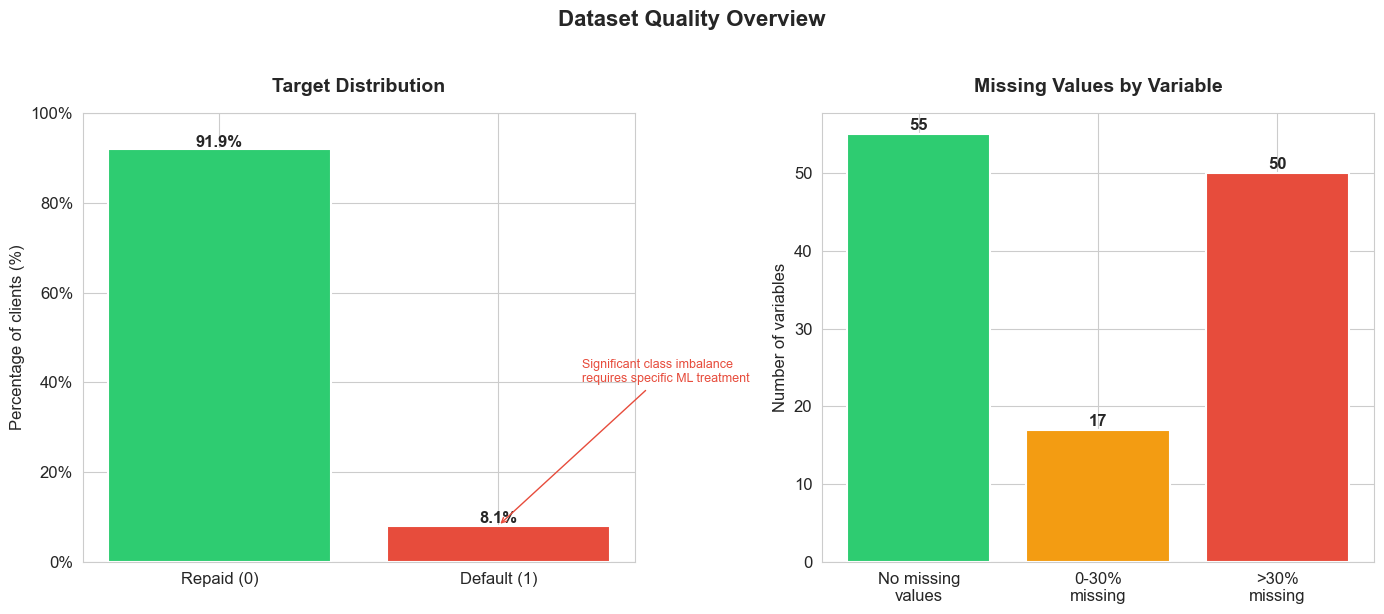

Chart saved in outputs/


In [11]:
# =============================================================================
# SECTION 2.1 - VISUALIZING CLASS IMBALANCE AND MISSING VALUES
# =============================================================================

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Plot 1 : Target distribution
colors = ['#2ecc71', '#e74c3c']
axes[0].bar(['Repaid (0)', 'Default (1)'],
            [target_pct[0], target_pct[1]],
            color=colors, edgecolor='white', linewidth=1.5)
axes[0].set_title('Target Distribution', fontsize=14, fontweight='bold', pad=15)
axes[0].set_ylabel('Percentage of clients (%)')
axes[0].yaxis.set_major_formatter(mtick.PercentFormatter())
for i, v in enumerate([target_pct[0], target_pct[1]]):
    axes[0].text(i, v + 0.5, f'{v:.1f}%', ha='center', fontweight='bold', fontsize=12)
axes[0].set_ylim(0, 100)
axes[0].annotate('Significant class imbalance\nrequires specific ML treatment',
                xy=(1, target_pct[1]),
                xytext=(1.3, 40),
                fontsize=9,
                color='#e74c3c',
                arrowprops=dict(arrowstyle='->', color='#e74c3c'))

# Plot 2 : Missing values distribution
labels = ['No missing\nvalues', '0-30%\nmissing', '>30%\nmissing']
values = [55, 17, 50]
colors2 = ['#2ecc71', '#f39c12', '#e74c3c']
bars = axes[1].bar(labels, values, color=colors2, edgecolor='white', linewidth=1.5)
axes[1].set_title('Missing Values by Variable', fontsize=14, fontweight='bold', pad=15)
axes[1].set_ylabel('Number of variables')
for bar, val in zip(bars, values):
    axes[1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
                str(val), ha='center', fontweight='bold', fontsize=12)

plt.suptitle('Dataset Quality Overview', fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('../outputs/01_dataset_overview.png', dpi=150, bbox_inches='tight')
plt.show()

print("Chart saved in outputs/")

### Section 2.2 — Target Variable Analysis

#### Industry Benchmark Context

To contextualize Home Credit's 8.1% default rate, we compared it against
publicly available default rates across different lending segments.

These benchmarks were sourced independently to provide business context :

| Segment | Default Rate | Source |
|---|---|---|
| Home Credit (this dataset) | 8.1% | Kaggle — Home Credit Default Risk |
| Bank Credit Cards | 3.04% | S&P/Experian Consumer Credit Default Index, January 2023 |
| Prime Lending (composite) | 0.69% | S&P/Experian Consumer Credit Default Index, January 2023 |
| Microfinance (portfolio at risk >30 days) | 5.8% | ATLAS Microfinance Data, 2023 |

**Key takeaway** : Home Credit operates in a high-risk segment, significantly above
retail banking but serving a population traditionally excluded from formal credit.
This is precisely the market opportunity our model aims to address.

> Sources :
> - S&P Dow Jones Indices & Experian, *Consumer Credit Default Index*, February 2023
> - fitsmallbusiness.com based on ATLAS data, *Microfinance Default Rates*, 2023

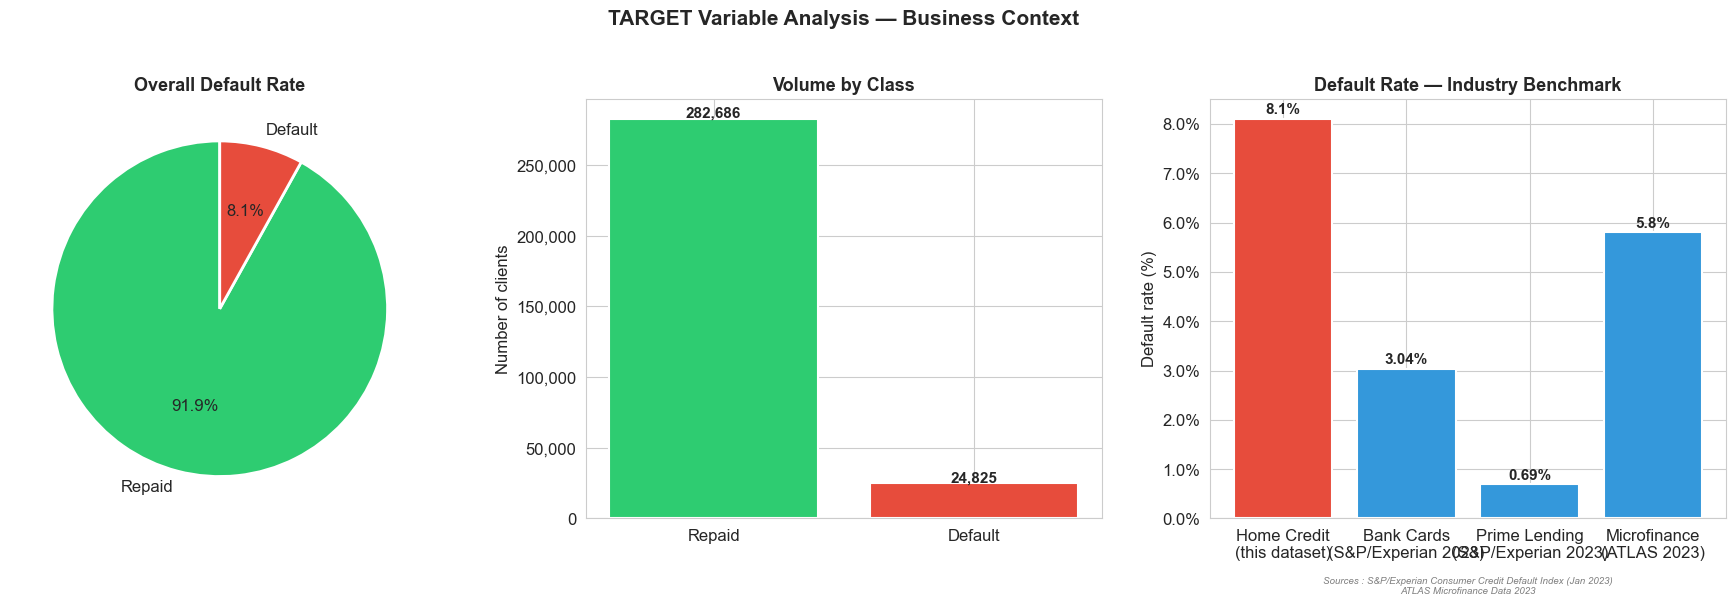

Business insight : With 24,825 defaults out of 307,511 clients,
each percentage point of threshold change affects ~3075 credit decisions.


In [12]:
# =============================================================================
# SECTION 2.2 - TARGET VARIABLE DEEP DIVE
# =============================================================================

fig, axes = plt.subplots(1, 3, figsize=(18, 6))

# Plot 1 : Pie chart
colors = ['#2ecc71', '#e74c3c']
axes[0].pie([target_pct[0], target_pct[1]],
            labels=['Repaid', 'Default'],
            colors=colors,
            autopct='%1.1f%%',
            startangle=90,
            wedgeprops=dict(edgecolor='white', linewidth=2))
axes[0].set_title('Overall Default Rate', fontsize=13, fontweight='bold')

# Plot 2 : Volume by class
volumes = [target_counts[0], target_counts[1]]
bars = axes[1].bar(['Repaid', 'Default'], volumes,
                   color=colors, edgecolor='white', linewidth=1.5)
axes[1].set_title('Volume by Class', fontsize=13, fontweight='bold')
axes[1].set_ylabel('Number of clients')
axes[1].yaxis.set_major_formatter(plt.FuncFormatter(lambda x, p: f'{x:,.0f}'))
for bar, vol in zip(bars, volumes):
    axes[1].text(bar.get_x() + bar.get_width()/2,
                bar.get_height() + 1000,
                f'{vol:,}', ha='center', fontweight='bold', fontsize=11)

# Plot 3 : Industry benchmark
categories = ['Home Credit\n(this dataset)', 'Bank Cards\n(S&P/Experian 2023)',
              'Prime Lending\n(S&P/Experian 2023)', 'Microfinance\n(ATLAS 2023)']
default_rates = [8.1, 3.04, 0.69, 5.8]
bar_colors = ['#e74c3c', '#3498db', '#3498db', '#3498db']
bars3 = axes[2].bar(categories, default_rates,
                    color=bar_colors, edgecolor='white', linewidth=1.5)
axes[2].set_title('Default Rate — Industry Benchmark', fontsize=13, fontweight='bold')
axes[2].set_ylabel('Default rate (%)')
axes[2].yaxis.set_major_formatter(mtick.PercentFormatter())
for bar, rate in zip(bars3, default_rates):
    axes[2].text(bar.get_x() + bar.get_width()/2,
                bar.get_height() + 0.1,
                f'{rate}%', ha='center', fontweight='bold', fontsize=11)
axes[2].annotate('Sources : S&P/Experian Consumer Credit Default Index (Jan 2023)\nATLAS Microfinance Data 2023',
                xy=(0.5, -0.18), xycoords='axes fraction',
                ha='center', fontsize=7, color='grey', style='italic')

plt.suptitle('TARGET Variable Analysis — Business Context',
             fontsize=15, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('../outputs/02_target_analysis.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"Business insight : With 24,825 defaults out of 307,511 clients,")
print(f"each percentage point of threshold change affects ~{307511*0.01:.0f} credit decisions.")

### Section 2.3 — Demographic Analysis

**Business question** : Do demographic characteristics influence default risk,
and if so, which profiles should a fintech prioritize or approach with caution ?

We analyze four key demographic variables :
- Age
- Gender
- Family status
- Property ownership (car and real estate)

In [13]:
# =============================================================================
# SECTION 2.3 - DEMOGRAPHIC ANALYSIS
# =============================================================================

# Convert DAYS_BIRTH to age in years (negative values -> positive age)
app_train['AGE_YEARS'] = (-app_train['DAYS_BIRTH'] / 365).astype(int)

# Create age buckets for business readability
age_bins = [0, 25, 35, 45, 55, 65, 100]
age_labels = ['<25', '25-35', '35-45', '45-55', '55-65', '65+']
app_train['AGE_GROUP'] = pd.cut(app_train['AGE_YEARS'],
                                 bins=age_bins,
                                 labels=age_labels)

# Compute default rate by age group
age_default = app_train.groupby('AGE_GROUP', observed=True)['TARGET'].agg(['mean', 'count'])
age_default.columns = ['default_rate', 'count']
age_default['default_rate_pct'] = age_default['default_rate'] * 100

# Compute default rate by gender
gender_default = app_train.groupby('CODE_GENDER')['TARGET'].agg(['mean', 'count'])
gender_default.columns = ['default_rate', 'count']
gender_default['default_rate_pct'] = gender_default['default_rate'] * 100

# Compute default rate by family status
family_default = app_train.groupby('NAME_FAMILY_STATUS')['TARGET'].agg(['mean', 'count'])
family_default.columns = ['default_rate', 'count']
family_default['default_rate_pct'] = family_default['default_rate'] * 100
family_default = family_default.sort_values('default_rate_pct', ascending=False)

# Compute default rate by property ownership
app_train['PROPERTY_PROFILE'] = 'No assets'
app_train.loc[(app_train['FLAG_OWN_CAR'] == 'Y') & 
              (app_train['FLAG_OWN_REALTY'] == 'N'), 'PROPERTY_PROFILE'] = 'Car only'
app_train.loc[(app_train['FLAG_OWN_CAR'] == 'N') & 
              (app_train['FLAG_OWN_REALTY'] == 'Y'), 'PROPERTY_PROFILE'] = 'Realty only'
app_train.loc[(app_train['FLAG_OWN_CAR'] == 'Y') & 
              (app_train['FLAG_OWN_REALTY'] == 'Y'), 'PROPERTY_PROFILE'] = 'Car + Realty'

property_default = app_train.groupby('PROPERTY_PROFILE')['TARGET'].agg(['mean', 'count'])
property_default.columns = ['default_rate', 'count']
property_default['default_rate_pct'] = property_default['default_rate'] * 100
property_default = property_default.sort_values('default_rate_pct', ascending=False)

print("Demographic aggregations computed successfully")
print(f"\nDefault rate by age group :\n{age_default[['default_rate_pct', 'count']].to_string()}")
print(f"\nDefault rate by gender :\n{gender_default[['default_rate_pct', 'count']].to_string()}")

Demographic aggregations computed successfully

Default rate by age group :
           default_rate_pct  count
AGE_GROUP                         
<25               11.741635  16318
25-35             10.585446  75925
35-45              8.237628  83677
45-55              6.848822  69501
55-65              5.343284  57081
65+                3.373927   5009

Default rate by gender :
             default_rate_pct   count
CODE_GENDER                          
F                    6.999328  202448
M                   10.141920  105059
XNA                  0.000000       4


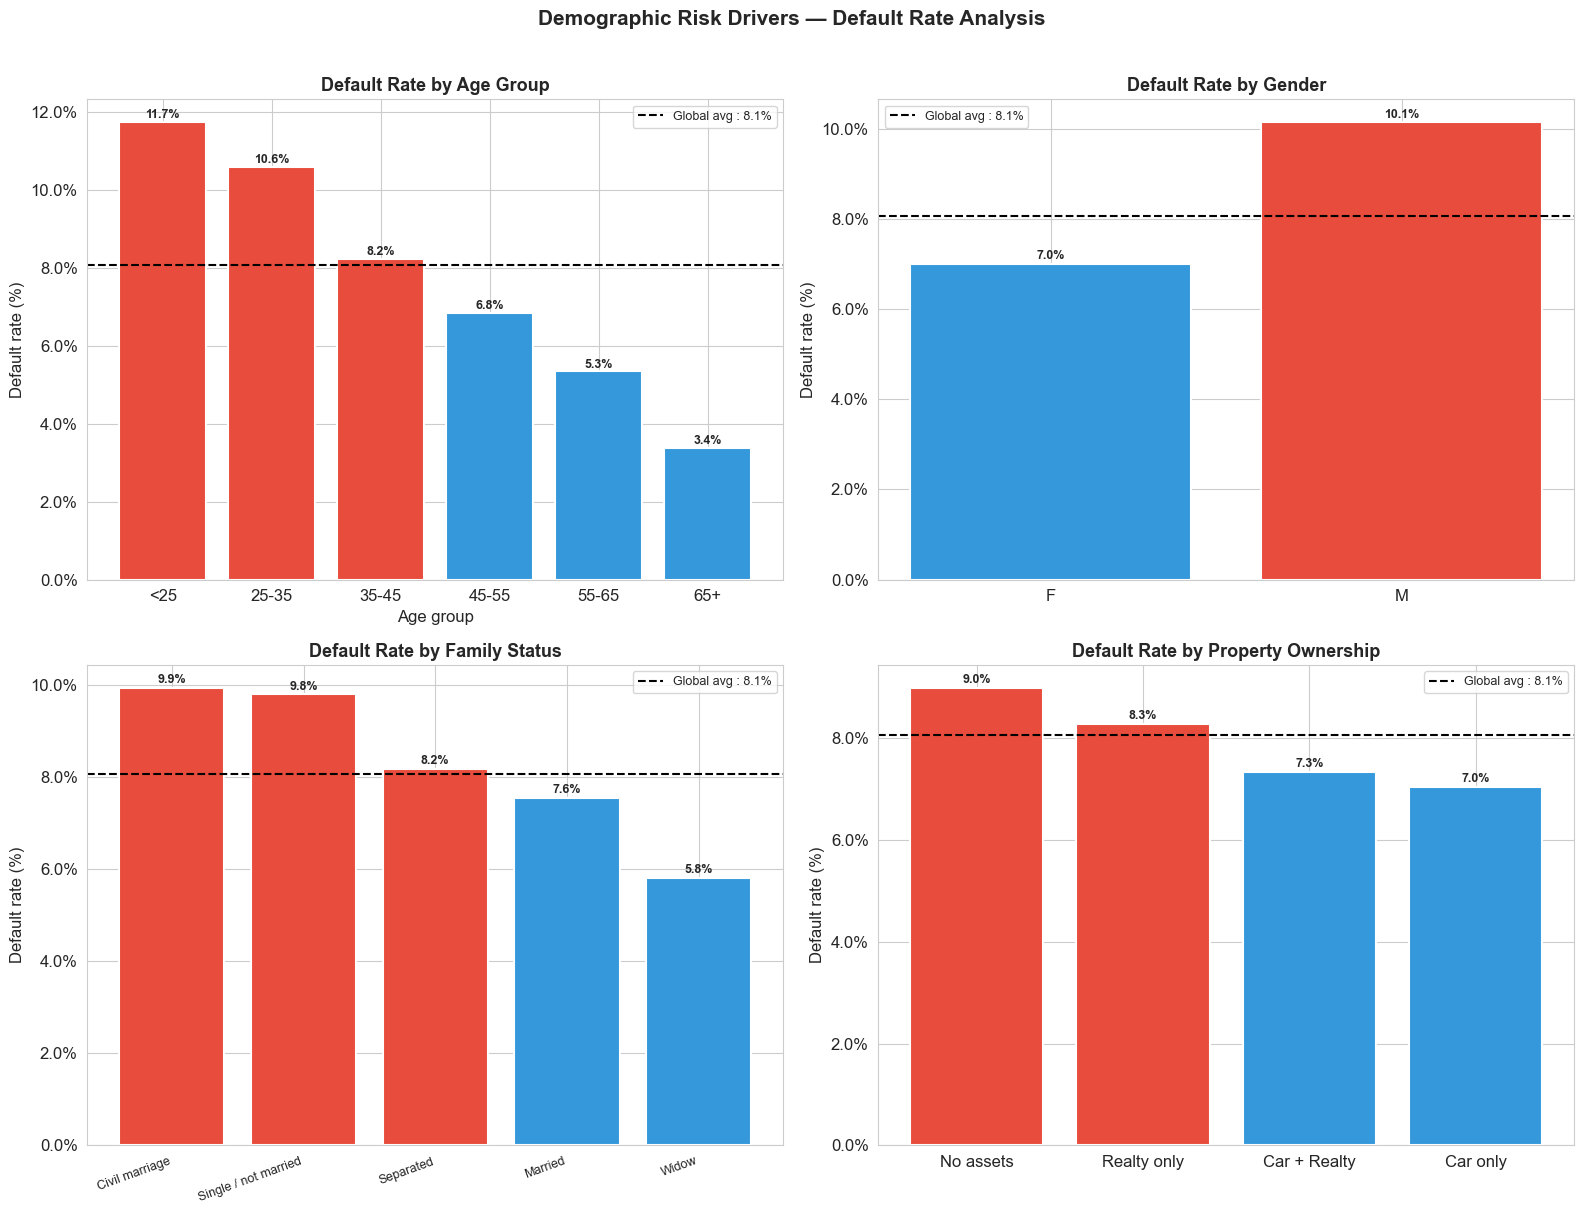

Chart saved in outputs/


In [15]:
# =============================================================================
# SECTION 2.3 - DEMOGRAPHIC VISUALIZATIONS
# =============================================================================

fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# Color palette
base_color = '#3498db'
highlight_color = '#e74c3c'
global_avg = app_train['TARGET'].mean() * 100

# Plot 1 : Default rate by age group
colors_age = [highlight_color if x > global_avg else base_color
              for x in age_default['default_rate_pct']]
bars = axes[0,0].bar(age_default.index,
                     age_default['default_rate_pct'],
                     color=colors_age, edgecolor='white', linewidth=1.5)
axes[0,0].axhline(y=global_avg, color='black', linestyle='--',
                   linewidth=1.5, label=f'Global avg : {global_avg:.1f}%')
axes[0,0].set_title('Default Rate by Age Group', fontsize=13, fontweight='bold')
axes[0,0].set_ylabel('Default rate (%)')
axes[0,0].set_xlabel('Age group')
axes[0,0].legend(fontsize=9)
axes[0,0].yaxis.set_major_formatter(mtick.PercentFormatter())
for bar, val in zip(bars, age_default['default_rate_pct']):
    axes[0,0].text(bar.get_x() + bar.get_width()/2,
                   bar.get_height() + 0.1,
                   f'{val:.1f}%', ha='center', fontsize=9, fontweight='bold')

# Plot 2 : Default rate by gender (excluding XNA)
gender_filtered = gender_default[gender_default.index != 'XNA']
colors_gender = [highlight_color if x > global_avg else base_color
                 for x in gender_filtered['default_rate_pct']]
bars2 = axes[0,1].bar(gender_filtered.index,
                      gender_filtered['default_rate_pct'],
                      color=colors_gender, edgecolor='white', linewidth=1.5)
axes[0,1].axhline(y=global_avg, color='black', linestyle='--',
                   linewidth=1.5, label=f'Global avg : {global_avg:.1f}%')
axes[0,1].set_title('Default Rate by Gender', fontsize=13, fontweight='bold')
axes[0,1].set_ylabel('Default rate (%)')
axes[0,1].legend(fontsize=9)
axes[0,1].yaxis.set_major_formatter(mtick.PercentFormatter())
for bar, val in zip(bars2, gender_filtered['default_rate_pct']):
    axes[0,1].text(bar.get_x() + bar.get_width()/2,
                   bar.get_height() + 0.1,
                   f'{val:.1f}%', ha='center', fontsize=9, fontweight='bold')

# Plot 3 : Default rate by family status (excluding Unknown)
family_filtered = family_default[family_default.index != 'Unknown']
colors_family = [highlight_color if x > global_avg else base_color
                 for x in family_filtered['default_rate_pct']]
bars3 = axes[1,0].bar(range(len(family_filtered)),
                      family_filtered['default_rate_pct'],
                      color=colors_family, edgecolor='white', linewidth=1.5)
axes[1,0].set_xticks(range(len(family_filtered)))
axes[1,0].set_xticklabels(family_filtered.index, rotation=20, ha='right', fontsize=9)
axes[1,0].axhline(y=global_avg, color='black', linestyle='--',
                   linewidth=1.5, label=f'Global avg : {global_avg:.1f}%')
axes[1,0].set_title('Default Rate by Family Status', fontsize=13, fontweight='bold')
axes[1,0].set_ylabel('Default rate (%)')
axes[1,0].legend(fontsize=9)
axes[1,0].yaxis.set_major_formatter(mtick.PercentFormatter())
for bar, val in zip(bars3, family_filtered['default_rate_pct']):
    axes[1,0].text(bar.get_x() + bar.get_width()/2,
                   bar.get_height() + 0.1,
                   f'{val:.1f}%', ha='center', fontsize=9, fontweight='bold')

# Plot 4 : Default rate by property ownership
colors_prop = [highlight_color if x > global_avg else base_color
               for x in property_default['default_rate_pct']]
bars4 = axes[1,1].bar(property_default.index,
                      property_default['default_rate_pct'],
                      color=colors_prop, edgecolor='white', linewidth=1.5)
axes[1,1].axhline(y=global_avg, color='black', linestyle='--',
                   linewidth=1.5, label=f'Global avg : {global_avg:.1f}%')
axes[1,1].set_title('Default Rate by Property Ownership', fontsize=13, fontweight='bold')
axes[1,1].set_ylabel('Default rate (%)')
axes[1,1].legend(fontsize=9)
axes[1,1].yaxis.set_major_formatter(mtick.PercentFormatter())
for bar, val in zip(bars4, property_default['default_rate_pct']):
    axes[1,1].text(bar.get_x() + bar.get_width()/2,
                   bar.get_height() + 0.1,
                   f'{val:.1f}%', ha='center', fontsize=9, fontweight='bold')

plt.suptitle('Demographic Risk Drivers — Default Rate Analysis',
             fontsize=15, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('../outputs/03_demographic_analysis.png', dpi=150, bbox_inches='tight')
plt.show()

print("Chart saved in outputs/")

### Section 2.4 — Income & Employment Analysis

**Business question** : Does income level and employment stability predict default risk ?
And more importantly : are there reliable borrowers among low-income or recently employed profiles
that traditional scoring systems would automatically reject ?

We analyze four key variables :
- Income level and distribution
- Income type (salaried, self-employed, pensioner...)
- Employment seniority
- Education level

In [16]:
# =============================================================================
# SECTION 2.4 - INCOME & EMPLOYMENT ANALYSIS
# =============================================================================

# --- Income analysis ---
# Create income buckets (in local currency units)
income_percentiles = app_train['AMT_INCOME_TOTAL'].quantile([0.2, 0.4, 0.6, 0.8])
print("Income distribution percentiles :")
print(income_percentiles)

income_bins = [0,
               income_percentiles[0.2],
               income_percentiles[0.4],
               income_percentiles[0.6],
               income_percentiles[0.8],
               app_train['AMT_INCOME_TOTAL'].max()]

income_labels = ['Very Low', 'Low', 'Medium', 'High', 'Very High']
app_train['INCOME_GROUP'] = pd.cut(app_train['AMT_INCOME_TOTAL'],
                                    bins=income_bins,
                                    labels=income_labels,
                                    duplicates='drop')

income_default = app_train.groupby('INCOME_GROUP', observed=True)['TARGET'].agg(['mean', 'count'])
income_default.columns = ['default_rate', 'count']
income_default['default_rate_pct'] = income_default['default_rate'] * 100

# --- Income type analysis ---
income_type_default = app_train.groupby('NAME_INCOME_TYPE')['TARGET'].agg(['mean', 'count'])
income_type_default.columns = ['default_rate', 'count']
income_type_default['default_rate_pct'] = income_type_default['default_rate'] * 100
income_type_default = income_type_default.sort_values('default_rate_pct', ascending=False)

# --- Employment seniority analysis ---
# Filter out the anomalous value (365243 = unemployed encoding)
employed = app_train[app_train['DAYS_EMPLOYED'] != 365243].copy()
employed['EMPLOYED_YEARS'] = (-employed['DAYS_EMPLOYED'] / 365).astype(int)

emp_bins = [0, 1, 3, 5, 10, 20, 100]
emp_labels = ['<1 yr', '1-3 yrs', '3-5 yrs', '5-10 yrs', '10-20 yrs', '20+ yrs']
employed['EMP_GROUP'] = pd.cut(employed['EMPLOYED_YEARS'],
                                bins=emp_bins,
                                labels=emp_labels)

emp_default = employed.groupby('EMP_GROUP', observed=True)['TARGET'].agg(['mean', 'count'])
emp_default.columns = ['default_rate', 'count']
emp_default['default_rate_pct'] = emp_default['default_rate'] * 100

# --- Education analysis ---
edu_default = app_train.groupby('NAME_EDUCATION_TYPE')['TARGET'].agg(['mean', 'count'])
edu_default.columns = ['default_rate', 'count']
edu_default['default_rate_pct'] = edu_default['default_rate'] * 100
edu_default = edu_default.sort_values('default_rate_pct', ascending=False)

print("\nDefault rate by income type :")
print(income_type_default[['default_rate_pct', 'count']].to_string())
print("\nDefault rate by employment seniority :")
print(emp_default[['default_rate_pct', 'count']].to_string())

Income distribution percentiles :
0.2     99000.0
0.4    135000.0
0.6    162000.0
0.8    225000.0
Name: AMT_INCOME_TOTAL, dtype: float64

Default rate by income type :
                      default_rate_pct   count
NAME_INCOME_TYPE                              
Maternity leave              40.000000       5
Unemployed                   36.363636      22
Working                       9.588472  158774
Commercial associate          7.484257   71617
State servant                 5.754965   21703
Pensioner                     5.386366   55362
Businessman                   0.000000      10
Student                       0.000000      18

Default rate by employment seniority :
           default_rate_pct  count
EMP_GROUP                         
<1 yr             11.403536  31841
1-3 yrs           10.453840  54755
3-5 yrs            8.701824  38038
5-10 yrs           7.019988  55983
10-20 yrs          5.254455  32658
20+ yrs            4.188721  10958


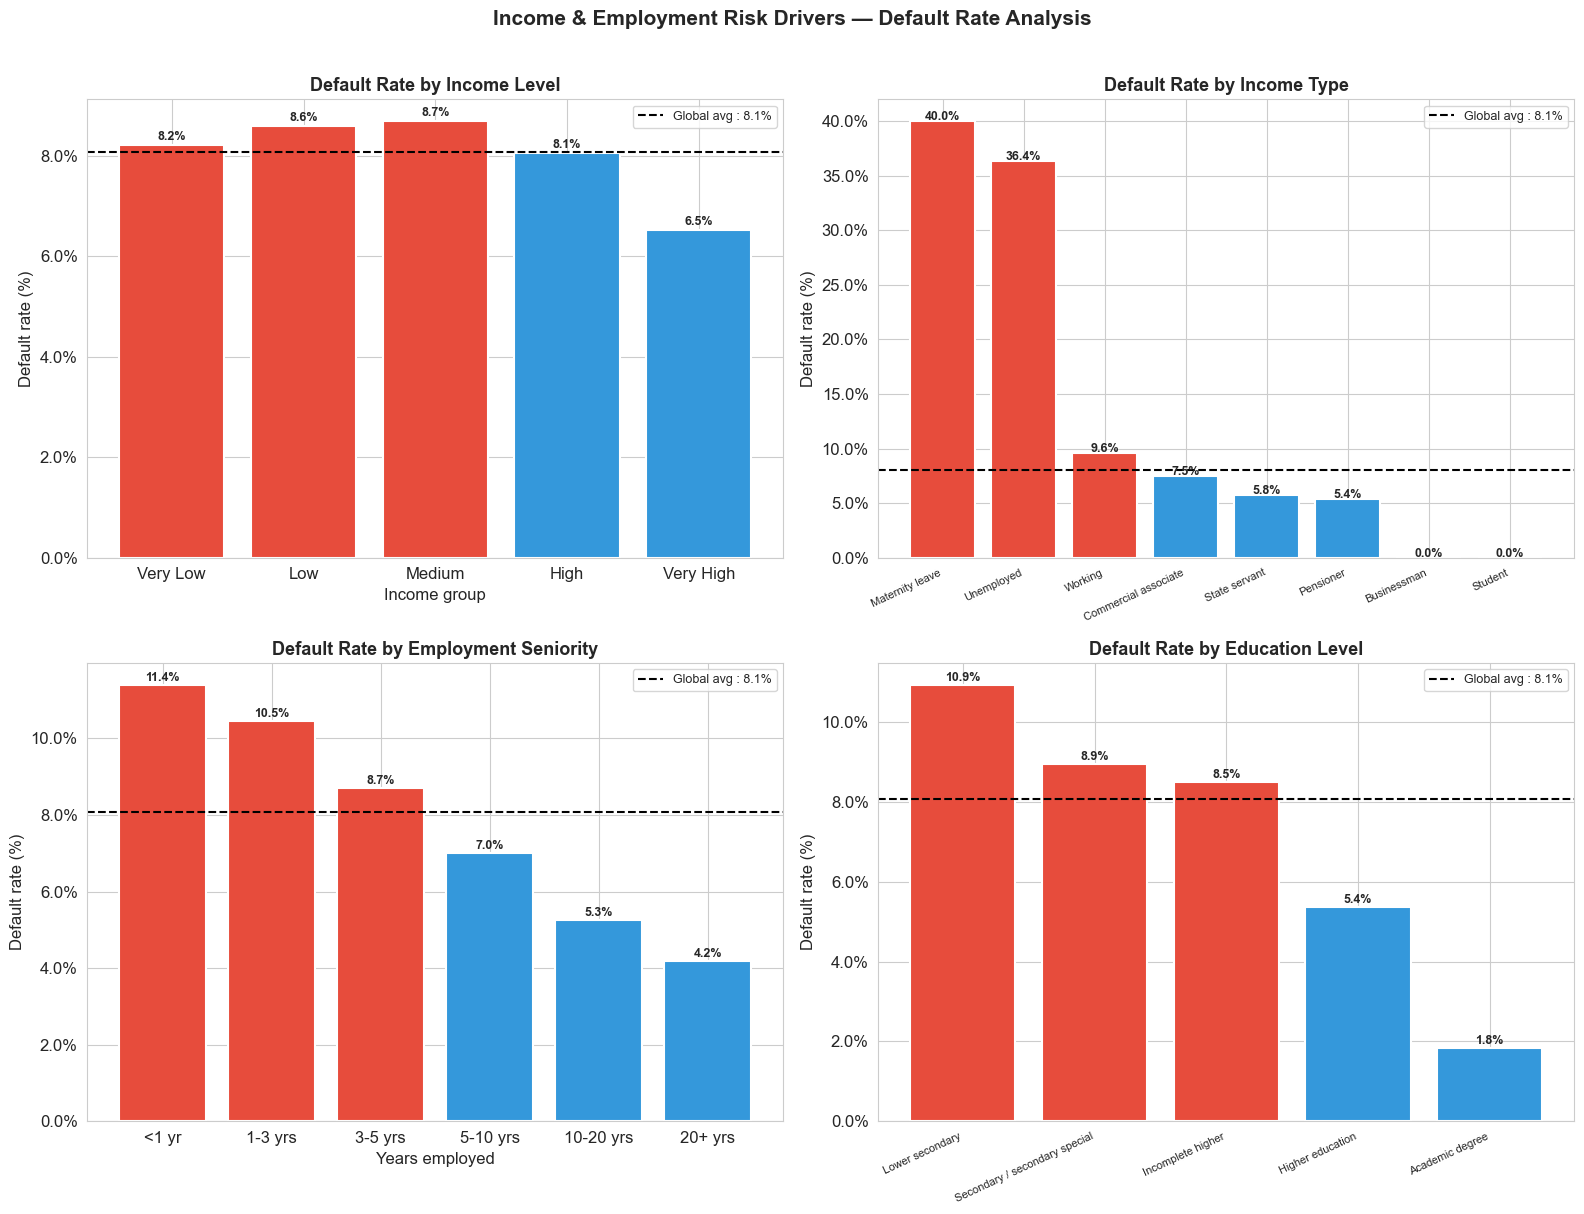

Chart saved in outputs/


In [17]:
# =============================================================================
# SECTION 2.4 - INCOME & EMPLOYMENT VISUALIZATIONS
# =============================================================================

fig, axes = plt.subplots(2, 2, figsize=(16, 12))

base_color = '#3498db'
highlight_color = '#e74c3c'
global_avg = app_train['TARGET'].mean() * 100

# Plot 1 : Default rate by income group
colors_inc = [highlight_color if x > global_avg else base_color
              for x in income_default['default_rate_pct']]
bars = axes[0,0].bar(income_default.index,
                     income_default['default_rate_pct'],
                     color=colors_inc, edgecolor='white', linewidth=1.5)
axes[0,0].axhline(y=global_avg, color='black', linestyle='--',
                   linewidth=1.5, label=f'Global avg : {global_avg:.1f}%')
axes[0,0].set_title('Default Rate by Income Level', fontsize=13, fontweight='bold')
axes[0,0].set_ylabel('Default rate (%)')
axes[0,0].set_xlabel('Income group')
axes[0,0].legend(fontsize=9)
axes[0,0].yaxis.set_major_formatter(mtick.PercentFormatter())
for bar, val in zip(bars, income_default['default_rate_pct']):
    axes[0,0].text(bar.get_x() + bar.get_width()/2,
                   bar.get_height() + 0.1,
                   f'{val:.1f}%', ha='center', fontsize=9, fontweight='bold')

# Plot 2 : Default rate by income type
colors_type = [highlight_color if x > global_avg else base_color
               for x in income_type_default['default_rate_pct']]
bars2 = axes[0,1].bar(range(len(income_type_default)),
                      income_type_default['default_rate_pct'],
                      color=colors_type, edgecolor='white', linewidth=1.5)
axes[0,1].set_xticks(range(len(income_type_default)))
axes[0,1].set_xticklabels(income_type_default.index, rotation=25, ha='right', fontsize=8)
axes[0,1].axhline(y=global_avg, color='black', linestyle='--',
                   linewidth=1.5, label=f'Global avg : {global_avg:.1f}%')
axes[0,1].set_title('Default Rate by Income Type', fontsize=13, fontweight='bold')
axes[0,1].set_ylabel('Default rate (%)')
axes[0,1].legend(fontsize=9)
axes[0,1].yaxis.set_major_formatter(mtick.PercentFormatter())
for bar, val in zip(bars2, income_type_default['default_rate_pct']):
    axes[0,1].text(bar.get_x() + bar.get_width()/2,
                   bar.get_height() + 0.1,
                   f'{val:.1f}%', ha='center', fontsize=9, fontweight='bold')

# Plot 3 : Default rate by employment seniority
colors_emp = [highlight_color if x > global_avg else base_color
              for x in emp_default['default_rate_pct']]
bars3 = axes[1,0].bar(emp_default.index,
                      emp_default['default_rate_pct'],
                      color=colors_emp, edgecolor='white', linewidth=1.5)
axes[1,0].axhline(y=global_avg, color='black', linestyle='--',
                   linewidth=1.5, label=f'Global avg : {global_avg:.1f}%')
axes[1,0].set_title('Default Rate by Employment Seniority', fontsize=13, fontweight='bold')
axes[1,0].set_ylabel('Default rate (%)')
axes[1,0].set_xlabel('Years employed')
axes[1,0].legend(fontsize=9)
axes[1,0].yaxis.set_major_formatter(mtick.PercentFormatter())
for bar, val in zip(bars3, emp_default['default_rate_pct']):
    axes[1,0].text(bar.get_x() + bar.get_width()/2,
                   bar.get_height() + 0.1,
                   f'{val:.1f}%', ha='center', fontsize=9, fontweight='bold')

# Plot 4 : Default rate by education level
colors_edu = [highlight_color if x > global_avg else base_color
              for x in edu_default['default_rate_pct']]
bars4 = axes[1,1].bar(range(len(edu_default)),
                      edu_default['default_rate_pct'],
                      color=colors_edu, edgecolor='white', linewidth=1.5)
axes[1,1].set_xticks(range(len(edu_default)))
axes[1,1].set_xticklabels(edu_default.index, rotation=25, ha='right', fontsize=8)
axes[1,1].axhline(y=global_avg, color='black', linestyle='--',
                   linewidth=1.5, label=f'Global avg : {global_avg:.1f}%')
axes[1,1].set_title('Default Rate by Education Level', fontsize=13, fontweight='bold')
axes[1,1].set_ylabel('Default rate (%)')
axes[1,1].legend(fontsize=9)
axes[1,1].yaxis.set_major_formatter(mtick.PercentFormatter())
for bar, val in zip(bars4, edu_default['default_rate_pct']):
    axes[1,1].text(bar.get_x() + bar.get_width()/2,
                   bar.get_height() + 0.1,
                   f'{val:.1f}%', ha='center', fontsize=9, fontweight='bold')

plt.suptitle('Income & Employment Risk Drivers — Default Rate Analysis',
             fontsize=15, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('../outputs/04_income_employment_analysis.png', dpi=150, bbox_inches='tight')
plt.show()

print("Chart saved in outputs/")

### Section 2.5 — Credit Variables Analysis

**Business question** : Does the loan structure itself — how much is borrowed,
relative to income and to the good's price — predict default risk ?

A client borrowing far beyond their repayment capacity is a risk signal
that traditional scoring often underweights. We analyze three key ratios
that any credit risk analyst would compute first :

- **Credit-to-Income ratio** : how many years of income does the loan represent ?
- **Annuity-to-Income ratio** : what share of monthly income goes to repayment ? (debt burden rate)
- **Credit-to-Goods ratio** : is the client borrowing more than the good is worth ?

These three ratios are standard tools in credit risk analysis worldwide.

In [18]:
# =============================================================================
# SECTION 2.5 - CREDIT VARIABLES ANALYSIS
# =============================================================================

# --- Compute key credit ratios ---

# Ratio 1 : Credit to Income
# How many years of income does the loan represent ?
app_train['CREDIT_INCOME_RATIO'] = app_train['AMT_CREDIT'] / app_train['AMT_INCOME_TOTAL']

# Ratio 2 : Annuity to Income (debt burden rate)
# What share of annual income goes to repayment ?
app_train['ANNUITY_INCOME_RATIO'] = app_train['AMT_ANNUITY'] / app_train['AMT_INCOME_TOTAL']

# Ratio 3 : Credit to Goods Price
# Is the client borrowing more than the good is worth ?
app_train['CREDIT_GOODS_RATIO'] = app_train['AMT_CREDIT'] / app_train['AMT_GOODS_PRICE']

# --- Create buckets for each ratio ---

# Credit to Income buckets
ci_bins = [0, 1, 2, 3, 5, 100]
ci_labels = ['<1x', '1-2x', '2-3x', '3-5x', '5x+']
app_train['CI_GROUP'] = pd.cut(app_train['CREDIT_INCOME_RATIO'],
                                bins=ci_bins, labels=ci_labels)

ci_default = app_train.groupby('CI_GROUP', observed=True)['TARGET'].agg(['mean', 'count'])
ci_default.columns = ['default_rate', 'count']
ci_default['default_rate_pct'] = ci_default['default_rate'] * 100

# Annuity to Income buckets
ai_bins = [0, 0.05, 0.10, 0.15, 0.20, 0.30, 1.0]
ai_labels = ['<5%', '5-10%', '10-15%', '15-20%', '20-30%', '30%+']
app_train['AI_GROUP'] = pd.cut(app_train['ANNUITY_INCOME_RATIO'],
                                bins=ai_bins, labels=ai_labels)

ai_default = app_train.groupby('AI_GROUP', observed=True)['TARGET'].agg(['mean', 'count'])
ai_default.columns = ['default_rate', 'count']
ai_default['default_rate_pct'] = ai_default['default_rate'] * 100

# Credit to Goods buckets
cg_bins = [0, 0.95, 1.0, 1.05, 1.10, 10.0]
cg_labels = ['<95%', '95-100%', '100-105%', '105-110%', '110%+']
app_train['CG_GROUP'] = pd.cut(app_train['CREDIT_GOODS_RATIO'],
                                bins=cg_bins, labels=cg_labels)

cg_default = app_train.groupby('CG_GROUP', observed=True)['TARGET'].agg(['mean', 'count'])
cg_default.columns = ['default_rate', 'count']
cg_default['default_rate_pct'] = cg_default['default_rate'] * 100

# Contract type
contract_default = app_train.groupby('NAME_CONTRACT_TYPE')['TARGET'].agg(['mean', 'count'])
contract_default.columns = ['default_rate', 'count']
contract_default['default_rate_pct'] = contract_default['default_rate'] * 100
contract_default = contract_default.sort_values('default_rate_pct', ascending=False)

print("Credit ratio aggregations computed successfully")
print(f"\nDefault rate by Credit/Income ratio :\n{ci_default.to_string()}")
print(f"\nDefault rate by Annuity/Income ratio :\n{ai_default.to_string()}")
print(f"\nDefault rate by Credit/Goods ratio :\n{cg_default.to_string()}")

Credit ratio aggregations computed successfully

Default rate by Credit/Income ratio :
          default_rate  count  default_rate_pct
CI_GROUP                                       
<1x           0.064363  16174          6.436256
1-2x          0.076956  60164          7.695632
2-3x          0.086898  64858          8.689753
3-5x          0.088354  85508          8.835431
5x+           0.073793  80807          7.379311

Default rate by Annuity/Income ratio :
          default_rate  count  default_rate_pct
AI_GROUP                                       
<5%           0.064742   7862          6.474180
5-10%         0.072870  49348          7.287023
10-15%        0.077251  78018          7.725140
15-20%        0.084418  67213          8.441819
20-30%        0.087643  73742          8.764341
30%+          0.081546  31283          8.154589

Default rate by Credit/Goods ratio :
          default_rate   count  default_rate_pct
CG_GROUP                                        
<95%          0.0

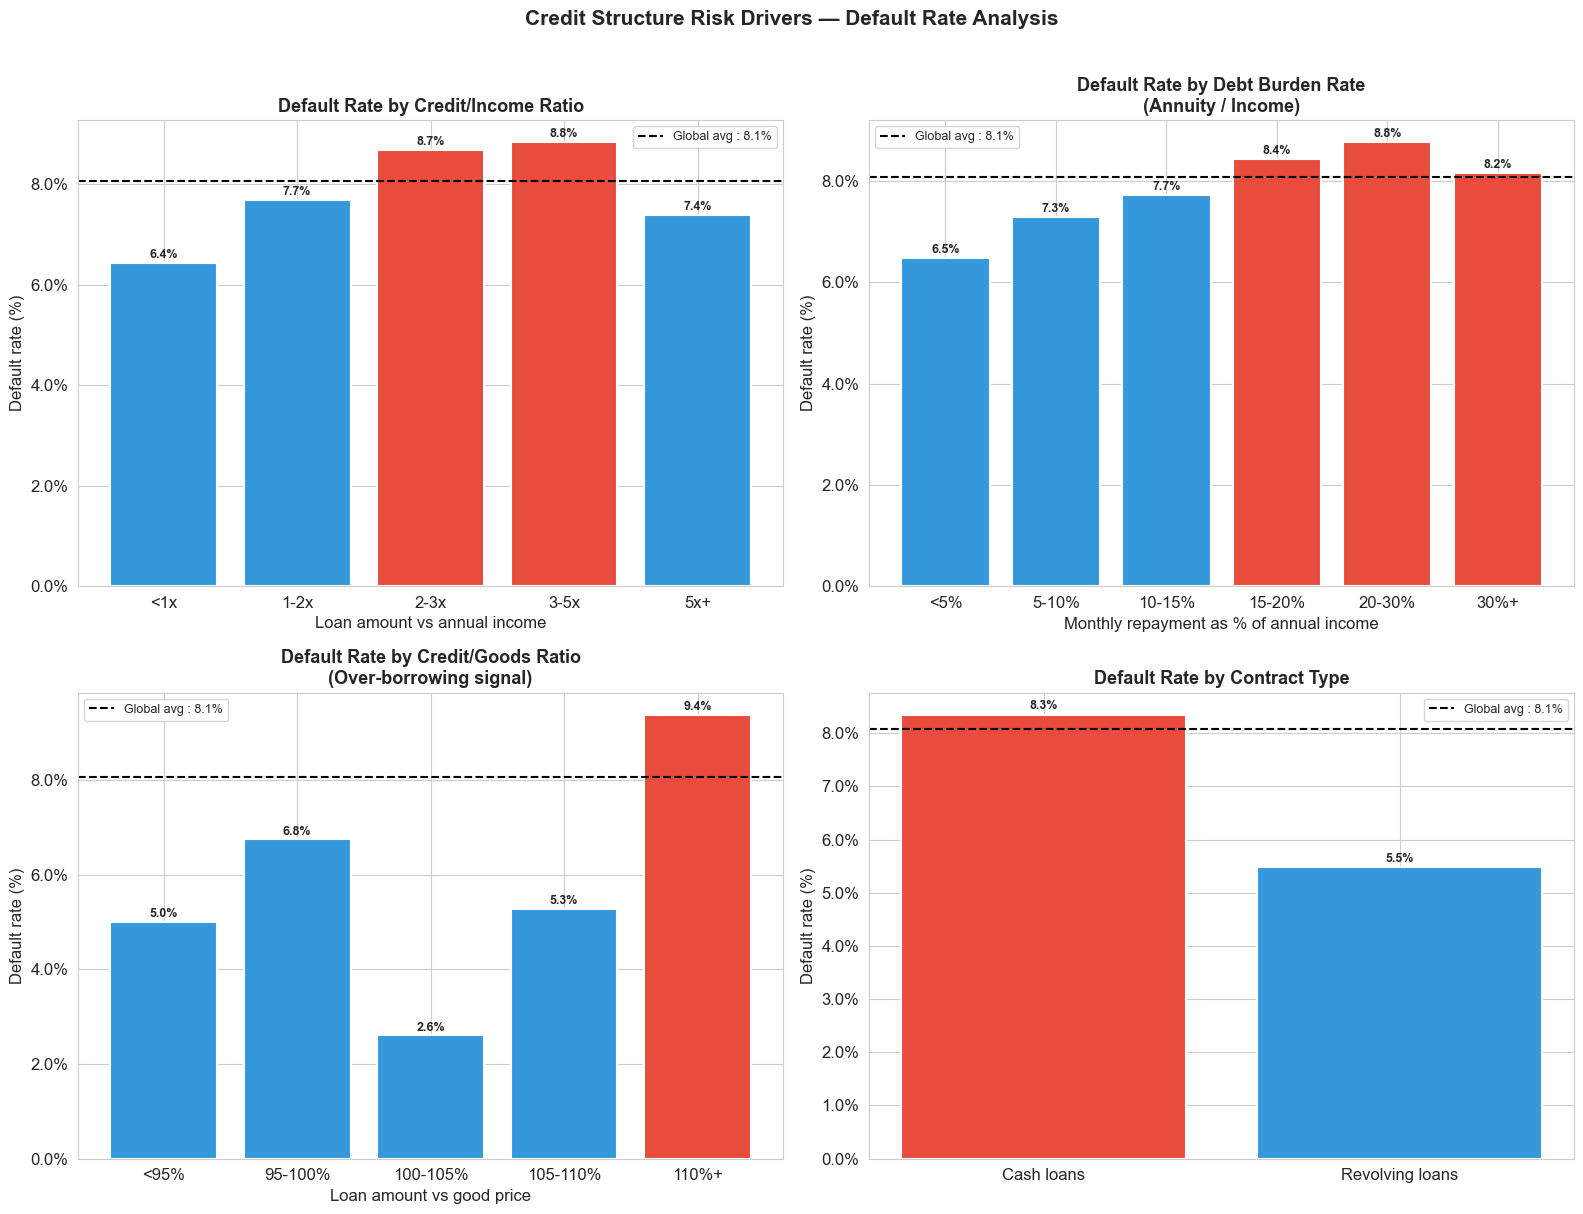

Chart saved in outputs/


In [19]:
# =============================================================================
# SECTION 2.5 - CREDIT VARIABLES VISUALIZATIONS
# =============================================================================

fig, axes = plt.subplots(2, 2, figsize=(16, 12))

base_color = '#3498db'
highlight_color = '#e74c3c'
global_avg = app_train['TARGET'].mean() * 100

# Plot 1 : Default rate by Credit/Income ratio
colors_ci = [highlight_color if x > global_avg else base_color
             for x in ci_default['default_rate_pct']]
bars = axes[0,0].bar(ci_default.index,
                     ci_default['default_rate_pct'],
                     color=colors_ci, edgecolor='white', linewidth=1.5)
axes[0,0].axhline(y=global_avg, color='black', linestyle='--',
                   linewidth=1.5, label=f'Global avg : {global_avg:.1f}%')
axes[0,0].set_title('Default Rate by Credit/Income Ratio', fontsize=13, fontweight='bold')
axes[0,0].set_ylabel('Default rate (%)')
axes[0,0].set_xlabel('Loan amount vs annual income')
axes[0,0].legend(fontsize=9)
axes[0,0].yaxis.set_major_formatter(mtick.PercentFormatter())
for bar, val in zip(bars, ci_default['default_rate_pct']):
    axes[0,0].text(bar.get_x() + bar.get_width()/2,
                   bar.get_height() + 0.1,
                   f'{val:.1f}%', ha='center', fontsize=9, fontweight='bold')

# Plot 2 : Default rate by Annuity/Income ratio (debt burden)
colors_ai = [highlight_color if x > global_avg else base_color
             for x in ai_default['default_rate_pct']]
bars2 = axes[0,1].bar(ai_default.index,
                      ai_default['default_rate_pct'],
                      color=colors_ai, edgecolor='white', linewidth=1.5)
axes[0,1].axhline(y=global_avg, color='black', linestyle='--',
                   linewidth=1.5, label=f'Global avg : {global_avg:.1f}%')
axes[0,1].set_title("Default Rate by Debt Burden Rate\n(Annuity / Income)",
                     fontsize=13, fontweight='bold')
axes[0,1].set_ylabel('Default rate (%)')
axes[0,1].set_xlabel('Monthly repayment as % of annual income')
axes[0,1].legend(fontsize=9)
axes[0,1].yaxis.set_major_formatter(mtick.PercentFormatter())
for bar, val in zip(bars2, ai_default['default_rate_pct']):
    axes[0,1].text(bar.get_x() + bar.get_width()/2,
                   bar.get_height() + 0.1,
                   f'{val:.1f}%', ha='center', fontsize=9, fontweight='bold')

# Plot 3 : Default rate by Credit/Goods ratio
colors_cg = [highlight_color if x > global_avg else base_color
             for x in cg_default['default_rate_pct']]
bars3 = axes[1,0].bar(cg_default.index,
                      cg_default['default_rate_pct'],
                      color=colors_cg, edgecolor='white', linewidth=1.5)
axes[1,0].axhline(y=global_avg, color='black', linestyle='--',
                   linewidth=1.5, label=f'Global avg : {global_avg:.1f}%')
axes[1,0].set_title('Default Rate by Credit/Goods Ratio\n(Over-borrowing signal)',
                     fontsize=13, fontweight='bold')
axes[1,0].set_ylabel('Default rate (%)')
axes[1,0].set_xlabel('Loan amount vs good price')
axes[1,0].legend(fontsize=9)
axes[1,0].yaxis.set_major_formatter(mtick.PercentFormatter())
for bar, val in zip(bars3, cg_default['default_rate_pct']):
    axes[1,0].text(bar.get_x() + bar.get_width()/2,
                   bar.get_height() + 0.1,
                   f'{val:.1f}%', ha='center', fontsize=9, fontweight='bold')

# Plot 4 : Default rate by contract type
colors_ct = [highlight_color if x > global_avg else base_color
             for x in contract_default['default_rate_pct']]
bars4 = axes[1,1].bar(contract_default.index,
                      contract_default['default_rate_pct'],
                      color=colors_ct, edgecolor='white', linewidth=1.5)
axes[1,1].axhline(y=global_avg, color='black', linestyle='--',
                   linewidth=1.5, label=f'Global avg : {global_avg:.1f}%')
axes[1,1].set_title('Default Rate by Contract Type', fontsize=13, fontweight='bold')
axes[1,1].set_ylabel('Default rate (%)')
axes[1,1].legend(fontsize=9)
axes[1,1].yaxis.set_major_formatter(mtick.PercentFormatter())
for bar, val in zip(bars4, contract_default['default_rate_pct']):
    axes[1,1].text(bar.get_x() + bar.get_width()/2,
                   bar.get_height() + 0.1,
                   f'{val:.1f}%', ha='center', fontsize=9, fontweight='bold')

plt.suptitle('Credit Structure Risk Drivers — Default Rate Analysis',
             fontsize=15, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('../outputs/05_credit_analysis.png', dpi=150, bbox_inches='tight')
plt.show()

print("Chart saved in outputs/")

### Section 2.6 — External Scores Analysis

**Business question** : Do alternative data sources capture risk signals
that traditional variables miss ? And can they identify reliable borrowers
among profiles that classical scoring would automatically reject ?

This section is the analytical core of our project. EXT_SOURCE_1, 2 and 3
are normalized scores (0 to 1) provided by external third-party providers.
Their exact methodology is undisclosed — which is itself a business limitation
we will address in our recommendations.

**Our hypothesis** : These alternative scores capture solvency signals
that declared variables (income, employment, demographics) do not fully explain.
If confirmed, this justifies a fintech's investment in alternative data sources
over traditional banking criteria.

In [20]:
# =============================================================================
# SECTION 2.6 - EXTERNAL SCORES ANALYSIS
# =============================================================================

# --- Basic statistics on EXT_SOURCE variables ---
ext_cols = ['EXT_SOURCE_1', 'EXT_SOURCE_2', 'EXT_SOURCE_3']

print("=" * 60)
print("EXT_SOURCE BASIC STATISTICS")
print("=" * 60)

for col in ext_cols:
    missing = app_train[col].isnull().sum()
    missing_pct = missing / len(app_train) * 100
    print(f"\n{col}")
    print(f"  Missing values : {missing:,} ({missing_pct:.1f}%)")
    print(f"  Mean           : {app_train[col].mean():.3f}")
    print(f"  Std            : {app_train[col].std():.3f}")
    print(f"  Min            : {app_train[col].min():.3f}")
    print(f"  Max            : {app_train[col].max():.3f}")

# --- Correlation with TARGET ---
print("\n" + "=" * 60)
print("CORRELATION WITH TARGET")
print("=" * 60)
for col in ext_cols:
    corr = app_train[col].corr(app_train['TARGET'])
    print(f"  {col} : {corr:.4f}")

# --- Correlation between EXT_SOURCE variables ---
print("\n" + "=" * 60)
print("CORRELATION BETWEEN EXT_SOURCE VARIABLES")
print("=" * 60)
ext_corr = app_train[ext_cols].corr()
print(ext_corr.to_string())

# --- Correlation with key traditional variables ---
print("\n" + "=" * 60)
print("CORRELATION WITH TRADITIONAL VARIABLES")
print("=" * 60)
traditional_vars = ['AMT_INCOME_TOTAL', 'DAYS_EMPLOYED', 'AGE_YEARS',
                    'CREDIT_INCOME_RATIO', 'ANNUITY_INCOME_RATIO']
for ext in ext_cols:
    print(f"\n{ext} correlations :")
    for trad in traditional_vars:
        if trad in app_train.columns:
            corr = app_train[ext].corr(app_train[trad])
            print(f"  vs {trad:<25} : {corr:.4f}")

# --- Create EXT_SOURCE buckets for visualization ---
for col in ext_cols:
    bucket_col = col + '_GROUP'
    app_train[bucket_col] = pd.cut(app_train[col],
                                    bins=[0, 0.2, 0.4, 0.6, 0.8, 1.0],
                                    labels=['0-0.2', '0.2-0.4', '0.4-0.6',
                                            '0.6-0.8', '0.8-1.0'])

ext1_default = app_train.groupby('EXT_SOURCE_1_GROUP', observed=True)['TARGET'].agg(['mean', 'count'])
ext1_default.columns = ['default_rate', 'count']
ext1_default['default_rate_pct'] = ext1_default['default_rate'] * 100

ext2_default = app_train.groupby('EXT_SOURCE_2_GROUP', observed=True)['TARGET'].agg(['mean', 'count'])
ext2_default.columns = ['default_rate', 'count']
ext2_default['default_rate_pct'] = ext2_default['default_rate'] * 100

ext3_default = app_train.groupby('EXT_SOURCE_3_GROUP', observed=True)['TARGET'].agg(['mean', 'count'])
ext3_default.columns = ['default_rate', 'count']
ext3_default['default_rate_pct'] = ext3_default['default_rate'] * 100

print("\nAggregations computed successfully")

EXT_SOURCE BASIC STATISTICS

EXT_SOURCE_1
  Missing values : 173,378 (56.4%)
  Mean           : 0.502
  Std            : 0.211
  Min            : 0.015
  Max            : 0.963

EXT_SOURCE_2
  Missing values : 660 (0.2%)
  Mean           : 0.514
  Std            : 0.191
  Min            : 0.000
  Max            : 0.855

EXT_SOURCE_3
  Missing values : 60,965 (19.8%)
  Mean           : 0.511
  Std            : 0.195
  Min            : 0.001
  Max            : 0.896

CORRELATION WITH TARGET
  EXT_SOURCE_1 : -0.1553
  EXT_SOURCE_2 : -0.1605
  EXT_SOURCE_3 : -0.1789

CORRELATION BETWEEN EXT_SOURCE VARIABLES
              EXT_SOURCE_1  EXT_SOURCE_2  EXT_SOURCE_3
EXT_SOURCE_1      1.000000      0.213982      0.186846
EXT_SOURCE_2      0.213982      1.000000      0.109167
EXT_SOURCE_3      0.186846      0.109167      1.000000

CORRELATION WITH TRADITIONAL VARIABLES

EXT_SOURCE_1 correlations :
  vs AMT_INCOME_TOTAL          : 0.0262
  vs DAYS_EMPLOYED             : 0.2898
  vs AGE_YEARS      

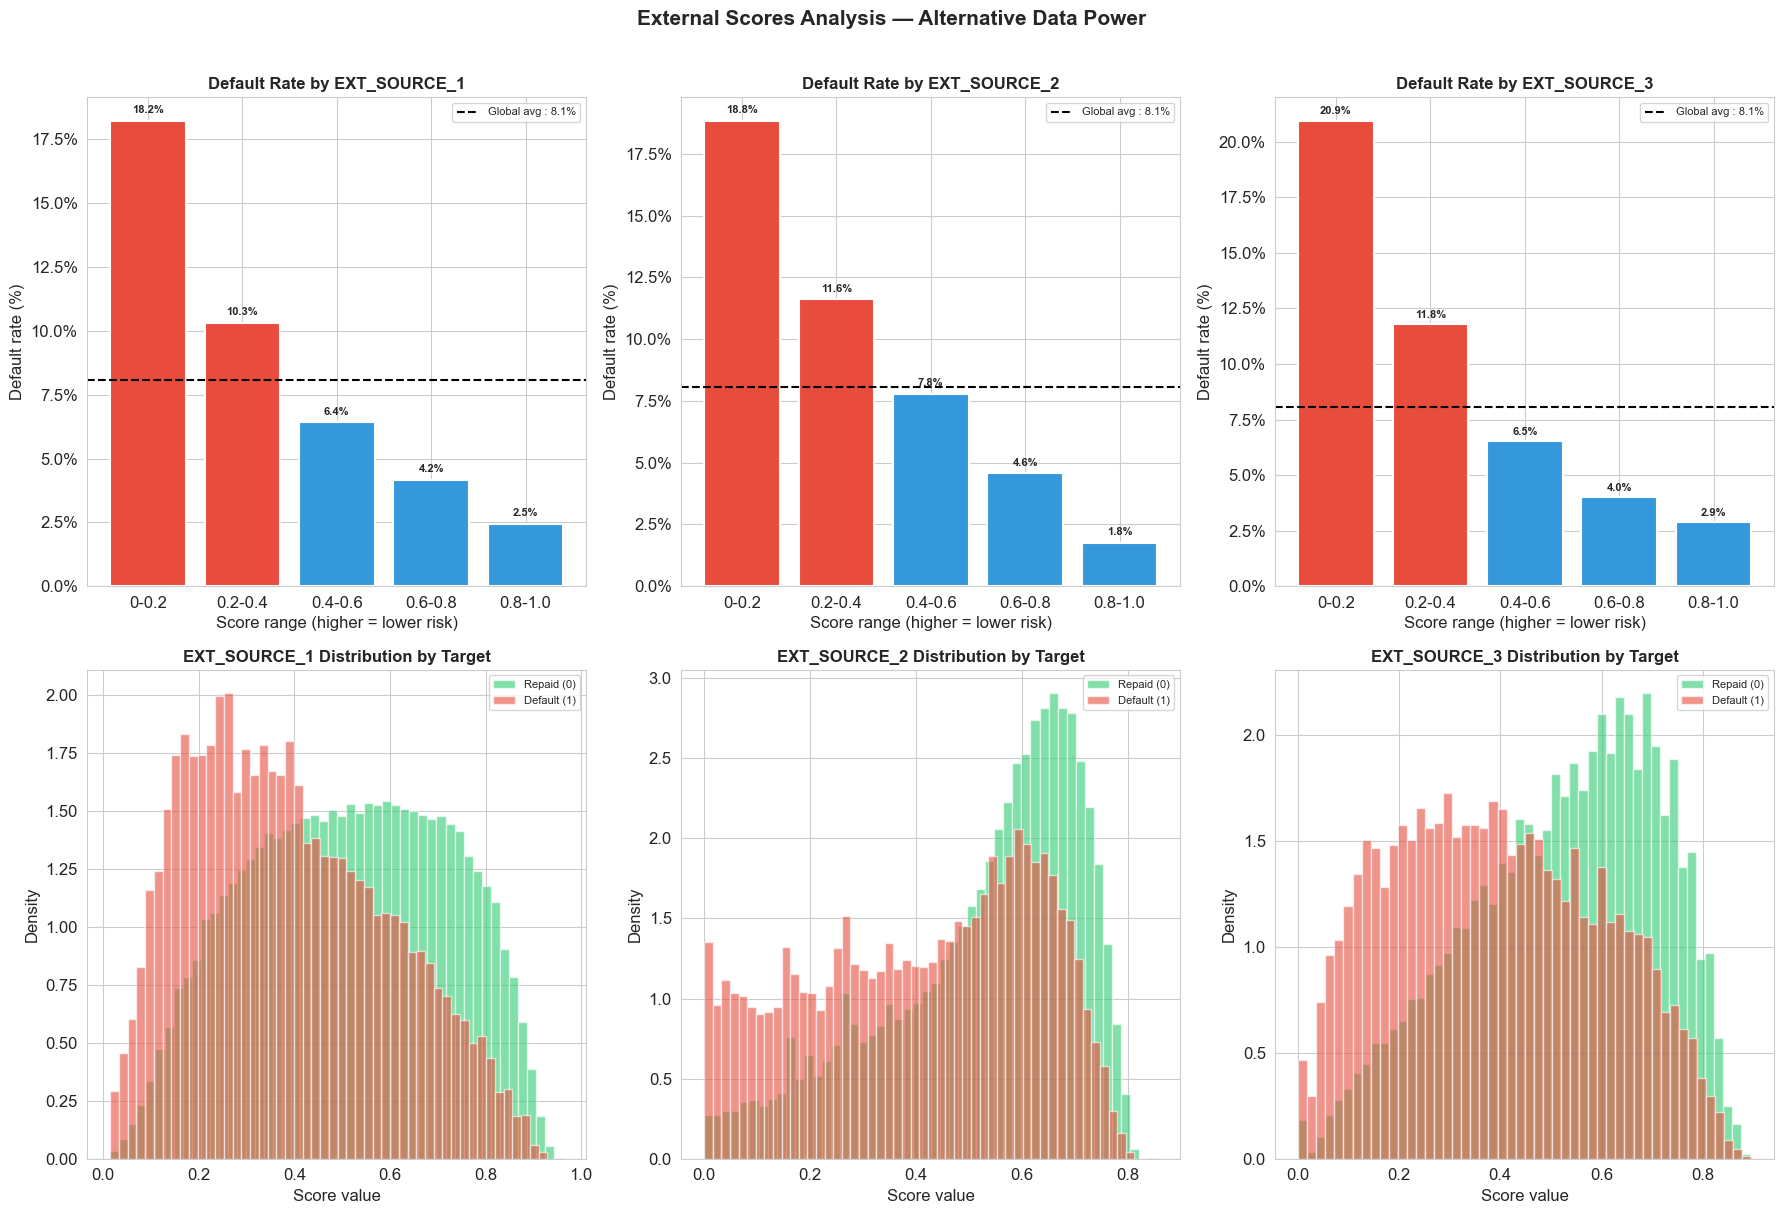

Chart saved in outputs/


In [21]:
# =============================================================================
# SECTION 2.6 - EXTERNAL SCORES VISUALIZATIONS
# =============================================================================

fig, axes = plt.subplots(2, 3, figsize=(18, 12))

base_color = '#3498db'
highlight_color = '#e74c3c'
global_avg = app_train['TARGET'].mean() * 100

# --- Row 1 : Default rate by EXT_SOURCE bucket ---

for i, (ext_default, col) in enumerate(zip(
        [ext1_default, ext2_default, ext3_default], ext_cols)):

    valid = ext_default.dropna()
    colors_ext = [highlight_color if x > global_avg else base_color
                  for x in valid['default_rate_pct']]
    bars = axes[0, i].bar(valid.index,
                          valid['default_rate_pct'],
                          color=colors_ext, edgecolor='white', linewidth=1.5)
    axes[0, i].axhline(y=global_avg, color='black', linestyle='--',
                        linewidth=1.5, label=f'Global avg : {global_avg:.1f}%')
    axes[0, i].set_title(f'Default Rate by {col}',
                          fontsize=12, fontweight='bold')
    axes[0, i].set_ylabel('Default rate (%)')
    axes[0, i].set_xlabel('Score range (higher = lower risk)')
    axes[0, i].legend(fontsize=8)
    axes[0, i].yaxis.set_major_formatter(mtick.PercentFormatter())
    for bar, val in zip(bars, valid['default_rate_pct']):
        axes[0, i].text(bar.get_x() + bar.get_width()/2,
                        bar.get_height() + 0.3,
                        f'{val:.1f}%', ha='center', fontsize=8, fontweight='bold')

# --- Row 2 : Distributions of EXT_SOURCE by TARGET ---

for i, col in enumerate(ext_cols):
    default_vals = app_train[app_train['TARGET'] == 1][col].dropna()
    repaid_vals = app_train[app_train['TARGET'] == 0][col].dropna()

    axes[1, i].hist(repaid_vals, bins=50, alpha=0.6,
                    color='#2ecc71', label='Repaid (0)', density=True)
    axes[1, i].hist(default_vals, bins=50, alpha=0.6,
                    color='#e74c3c', label='Default (1)', density=True)
    axes[1, i].set_title(f'{col} Distribution by Target',
                          fontsize=12, fontweight='bold')
    axes[1, i].set_xlabel('Score value')
    axes[1, i].set_ylabel('Density')
    axes[1, i].legend(fontsize=8)

plt.suptitle('External Scores Analysis — Alternative Data Power',
             fontsize=15, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('../outputs/06_external_scores.png', dpi=150, bbox_inches='tight')
plt.show()

print("Chart saved in outputs/")

### Section 2.7 — Financial Distress Signals

**Business question** : Does recent credit-seeking behavior reveal hidden financial stress
that declared variables do not capture ?

A client who applies for multiple loans in a short period is a classic red flag
in credit risk analysis. This behavior — known as "credit shopping" — often signals
that the client is being rejected elsewhere and is desperately seeking liquidity.

We analyze the AMT_REQ_CREDIT_BUREAU variables, which count how many times
a client's credit history was consulted by other institutions in recent periods :
- Last hour
- Last day
- Last week
- Last month
- Last quarter
- Last year

In [23]:
# =============================================================================
# SECTION 2.7 - FINANCIAL DISTRESS SIGNALS
# =============================================================================

req_cols = ['AMT_REQ_CREDIT_BUREAU_HOUR',
            'AMT_REQ_CREDIT_BUREAU_DAY',
            'AMT_REQ_CREDIT_BUREAU_WEEK',
            'AMT_REQ_CREDIT_BUREAU_MON',
            'AMT_REQ_CREDIT_BUREAU_QRT',
            'AMT_REQ_CREDIT_BUREAU_YEAR']

# --- Basic statistics ---
print("=" * 60)
print("CREDIT BUREAU ENQUIRIES — BASIC STATISTICS")
print("=" * 60)

for col in req_cols:
    missing_pct = app_train[col].isnull().sum() / len(app_train) * 100
    mean_val = app_train[col].mean()
    max_val = app_train[col].max()
    corr = app_train[col].corr(app_train['TARGET'])
    print(f"\n{col}")
    print(f"  Missing  : {missing_pct:.1f}%")
    print(f"  Mean     : {mean_val:.3f}")
    print(f"  Max      : {max_val:.0f}")
    print(f"  Corr with TARGET : {corr:.4f}")

# --- Default rate by number of enquiries (yearly) ---
# Cap at 10+ to avoid noise from extreme values
app_train['REQ_YEAR_CAPPED'] = app_train['AMT_REQ_CREDIT_BUREAU_YEAR'].clip(upper=10)

req_year_default = app_train.groupby('REQ_YEAR_CAPPED')['TARGET'].agg(['mean', 'count'])
req_year_default.columns = ['default_rate', 'count']
req_year_default['default_rate_pct'] = req_year_default['default_rate'] * 100

# --- Default rate by number of enquiries (monthly) ---
app_train['REQ_MON_CAPPED'] = app_train['AMT_REQ_CREDIT_BUREAU_MON'].clip(upper=5)

req_mon_default = app_train.groupby('REQ_MON_CAPPED')['TARGET'].agg(['mean', 'count'])
req_mon_default.columns = ['default_rate', 'count']
req_mon_default['default_rate_pct'] = req_mon_default['default_rate'] * 100

# --- Create distress signal : multiple recent enquiries ---
app_train['DISTRESS_SIGNAL'] = 'No signal'
app_train.loc[app_train['AMT_REQ_CREDIT_BUREAU_MON'] >= 3, 'DISTRESS_SIGNAL'] = 'Moderate (3+ monthly)'
app_train.loc[app_train['AMT_REQ_CREDIT_BUREAU_WEEK'] >= 2, 'DISTRESS_SIGNAL'] = 'High (2+ weekly)'
app_train.loc[app_train['AMT_REQ_CREDIT_BUREAU_DAY'] >= 1, 'DISTRESS_SIGNAL'] = 'Critical (same day)'

distress_default = app_train.groupby('DISTRESS_SIGNAL')['TARGET'].agg(['mean', 'count'])
distress_default.columns = ['default_rate', 'count']
distress_default['default_rate_pct'] = distress_default['default_rate'] * 100
distress_default = distress_default.sort_values('default_rate_pct', ascending=False)

print("\nDefault rate by distress signal :")
print(distress_default.to_string())

CREDIT BUREAU ENQUIRIES — BASIC STATISTICS

AMT_REQ_CREDIT_BUREAU_HOUR
  Missing  : 13.5%
  Mean     : 0.006
  Max      : 4
  Corr with TARGET : 0.0009

AMT_REQ_CREDIT_BUREAU_DAY
  Missing  : 13.5%
  Mean     : 0.007
  Max      : 9
  Corr with TARGET : 0.0027

AMT_REQ_CREDIT_BUREAU_WEEK
  Missing  : 13.5%
  Mean     : 0.034
  Max      : 8
  Corr with TARGET : 0.0008

AMT_REQ_CREDIT_BUREAU_MON
  Missing  : 13.5%
  Mean     : 0.267
  Max      : 27
  Corr with TARGET : -0.0125

AMT_REQ_CREDIT_BUREAU_QRT
  Missing  : 13.5%
  Mean     : 0.265
  Max      : 261
  Corr with TARGET : -0.0020

AMT_REQ_CREDIT_BUREAU_YEAR
  Missing  : 13.5%
  Mean     : 1.900
  Max      : 25
  Corr with TARGET : 0.0199

Default rate by distress signal :
                       default_rate   count  default_rate_pct
DISTRESS_SIGNAL                                              
High (2+ weekly)           0.103139     223         10.313901
Critical (same day)        0.094694    1489          9.469443
No signal        

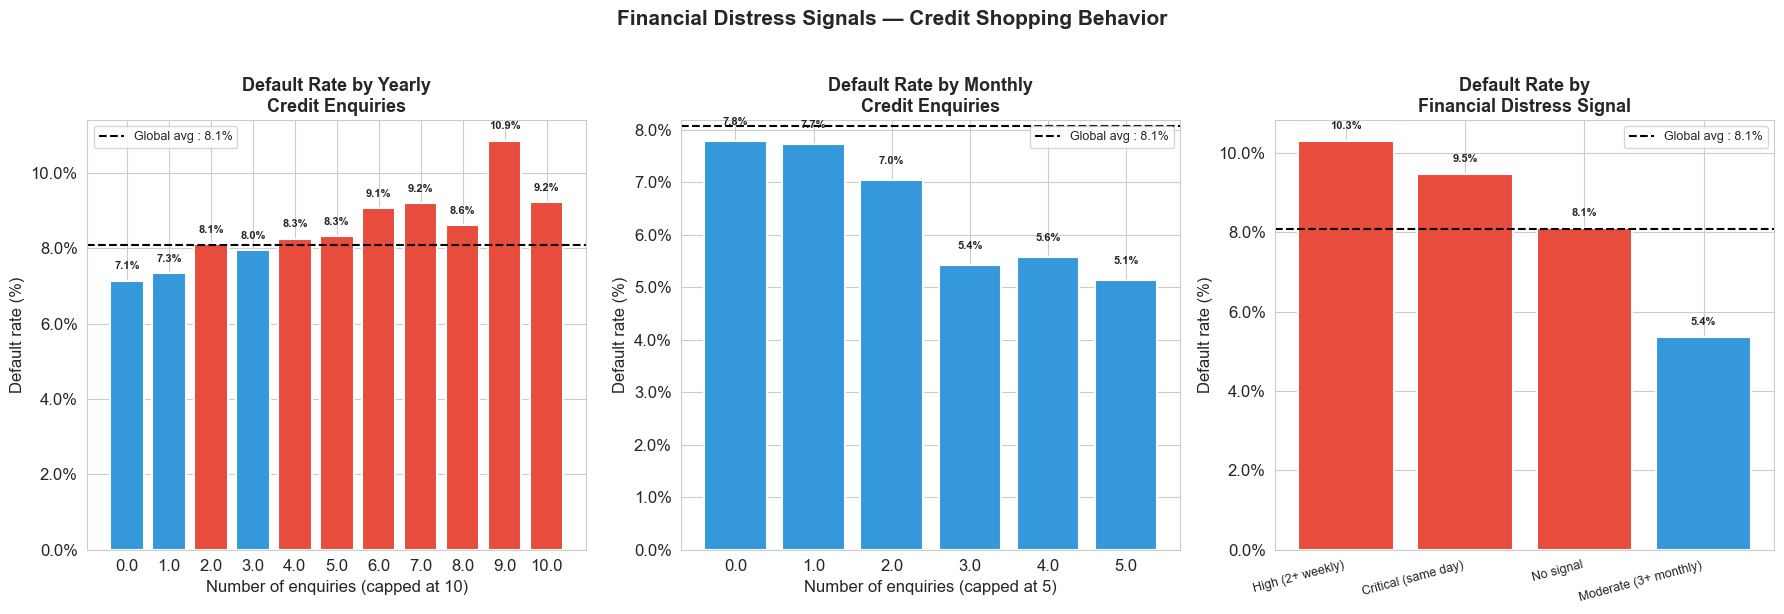

Chart saved in outputs/


In [24]:
# =============================================================================
# SECTION 2.7 - FINANCIAL DISTRESS VISUALIZATIONS
# =============================================================================

fig, axes = plt.subplots(1, 3, figsize=(18, 6))

base_color = '#3498db'
highlight_color = '#e74c3c'
global_avg = app_train['TARGET'].mean() * 100

# Plot 1 : Default rate by yearly enquiries
colors_year = [highlight_color if x > global_avg else base_color
               for x in req_year_default['default_rate_pct']]
bars = axes[0].bar(req_year_default.index.astype(str),
                   req_year_default['default_rate_pct'],
                   color=colors_year, edgecolor='white', linewidth=1.5)
axes[0].axhline(y=global_avg, color='black', linestyle='--',
                linewidth=1.5, label=f'Global avg : {global_avg:.1f}%')
axes[0].set_title('Default Rate by Yearly\nCredit Enquiries',
                   fontsize=13, fontweight='bold')
axes[0].set_ylabel('Default rate (%)')
axes[0].set_xlabel('Number of enquiries (capped at 10)')
axes[0].legend(fontsize=9)
axes[0].yaxis.set_major_formatter(mtick.PercentFormatter())
for bar, val in zip(bars, req_year_default['default_rate_pct']):
    axes[0].text(bar.get_x() + bar.get_width()/2,
                 bar.get_height() + 0.3,
                 f'{val:.1f}%', ha='center', fontsize=8, fontweight='bold')

# Plot 2 : Default rate by monthly enquiries
colors_mon = [highlight_color if x > global_avg else base_color
              for x in req_mon_default['default_rate_pct']]
bars2 = axes[1].bar(req_mon_default.index.astype(str),
                    req_mon_default['default_rate_pct'],
                    color=colors_mon, edgecolor='white', linewidth=1.5)
axes[1].axhline(y=global_avg, color='black', linestyle='--',
                linewidth=1.5, label=f'Global avg : {global_avg:.1f}%')
axes[1].set_title('Default Rate by Monthly\nCredit Enquiries',
                   fontsize=13, fontweight='bold')
axes[1].set_ylabel('Default rate (%)')
axes[1].set_xlabel('Number of enquiries (capped at 5)')
axes[1].legend(fontsize=9)
axes[1].yaxis.set_major_formatter(mtick.PercentFormatter())
for bar, val in zip(bars2, req_mon_default['default_rate_pct']):
    axes[1].text(bar.get_x() + bar.get_width()/2,
                 bar.get_height() + 0.3,
                 f'{val:.1f}%', ha='center', fontsize=8, fontweight='bold')

# Plot 3 : Distress signal
colors_dist = [highlight_color if x > global_avg else base_color
               for x in distress_default['default_rate_pct']]
bars3 = axes[2].bar(range(len(distress_default)),
                    distress_default['default_rate_pct'],
                    color=colors_dist, edgecolor='white', linewidth=1.5)
axes[2].set_xticks(range(len(distress_default)))
axes[2].set_xticklabels(distress_default.index, rotation=15, ha='right', fontsize=9)
axes[2].axhline(y=global_avg, color='black', linestyle='--',
                linewidth=1.5, label=f'Global avg : {global_avg:.1f}%')
axes[2].set_title('Default Rate by\nFinancial Distress Signal',
                   fontsize=13, fontweight='bold')
axes[2].set_ylabel('Default rate (%)')
axes[2].legend(fontsize=9)
axes[2].yaxis.set_major_formatter(mtick.PercentFormatter())
for bar, val in zip(bars3, distress_default['default_rate_pct']):
    axes[2].text(bar.get_x() + bar.get_width()/2,
                 bar.get_height() + 0.3,
                 f'{val:.1f}%', ha='center', fontsize=8, fontweight='bold')

plt.suptitle('Financial Distress Signals — Credit Shopping Behavior',
             fontsize=15, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('../outputs/07_distress_signals.png', dpi=150, bbox_inches='tight')
plt.show()

print("Chart saved in outputs/")

### Section 2.8 — EDA Synthesis

Before moving to feature engineering, we summarize the key findings
from our exploratory analysis. Every observation below directly informs
a modeling or business decision in the next phases.

In [25]:
# =============================================================================
# SECTION 2.8 - EDA SYNTHESIS
# =============================================================================

print("=" * 70)
print("EDA SYNTHESIS — KEY FINDINGS")
print("=" * 70)

print("""
FINDING 1 — CLASS IMBALANCE
─────────────────────────────────────────────────────────────────────
Observation  : 91.9% repaid vs 8.1% default.
ML impact    : A naive model predicting "no default" for everyone would
               reach 91.9% accuracy without learning anything.
Action       : We will use class-weight balancing in LightGBM and evaluate
               with precision-recall metrics, not just accuracy.

FINDING 2 — DEMOGRAPHIC RISK DRIVERS
─────────────────────────────────────────────────────────────────────
Observation  : Young clients (<25), single males, clients with no assets
               show significantly higher default rates.
Business     : These profiles are systematically excluded by traditional
               banking — yet not all of them are bad risks.
Action       : Age, gender, family status and property profile will be
               retained as features. The model will nuance what raw
               demographics cannot.

FINDING 3 — INCOME & EMPLOYMENT STABILITY
─────────────────────────────────────────────────────────────────────
Observation  : Short employment tenure (<1yr), low education, unstable
               income types (maternity leave, unemployed) drive default up.
Business     : Stable income predictability matters more than income level.
               A modest but regular income outperforms a high volatile one.
Action       : We will create an EMPLOYMENT_AGE_RATIO feature to capture
               stability relative to life stage.

FINDING 4 — CREDIT STRUCTURE RISK
─────────────────────────────────────────────────────────────────────
Observation  : Debt burden above 15% of income and over-borrowing relative
               to goods price (ratio > 1.0) are strong default predictors.
Business     : These are actionable underwriting criteria — a fintech can
               set hard limits on these ratios at the application stage.
Action       : CREDIT_INCOME_RATIO, ANNUITY_INCOME_RATIO and
               CREDIT_GOODS_RATIO will be core engineered features.

FINDING 5 — ALTERNATIVE SCORES POWER
─────────────────────────────────────────────────────────────────────
Observation  : EXT_SOURCE_2 and EXT_SOURCE_3 are among the strongest
               predictors of default, yet they are nearly uncorrelated
               with traditional variables (income, age, employment).
Business     : Alternative data captures solvency signals that declared
               variables miss entirely. This is the core argument for
               fintech investment in non-traditional data sources.
Action       : All three EXT_SOURCE variables will be prioritized features.
               Missing values will be imputed carefully to avoid information loss.

FINDING 6 — FINANCIAL DISTRESS SIGNALS
─────────────────────────────────────────────────────────────────────
Observation  : 2+ credit enquiries per week is the strongest distress
               signal (+27% above average default rate).
               Paradoxically, 3+ monthly enquiries correlates with LOWER
               default — this reflects rational credit shopping behavior.
Business     : Frequency and recency of credit seeking must be interpreted
               together, not in isolation.
Action       : We will engineer a composite DISTRESS_SIGNAL feature
               combining weekly and daily enquiry counts.
""")

print("=" * 70)
print("VARIABLES PRIORITIZED FOR FEATURE ENGINEERING")
print("=" * 70)

priority_vars = {
    'Alternative scores'    : ['EXT_SOURCE_1', 'EXT_SOURCE_2', 'EXT_SOURCE_3'],
    'Credit ratios'         : ['CREDIT_INCOME_RATIO', 'ANNUITY_INCOME_RATIO',
                               'CREDIT_GOODS_RATIO'],
    'Demographics'          : ['AGE_YEARS', 'CODE_GENDER', 'NAME_FAMILY_STATUS',
                               'PROPERTY_PROFILE'],
    'Employment'            : ['DAYS_EMPLOYED', 'NAME_INCOME_TYPE',
                               'NAME_EDUCATION_TYPE', 'ORGANIZATION_TYPE'],
    'Distress signals'      : ['AMT_REQ_CREDIT_BUREAU_WEEK',
                               'AMT_REQ_CREDIT_BUREAU_YEAR'],
    'To be engineered'      : ['EMPLOYMENT_AGE_RATIO', 'DISTRESS_SIGNAL',
                               'INCOME_PER_PERSON']
}

for category, variables in priority_vars.items():
    print(f"\n  {category} :")
    for var in variables:
        print(f"    → {var}")

EDA SYNTHESIS — KEY FINDINGS

FINDING 1 — CLASS IMBALANCE
─────────────────────────────────────────────────────────────────────
Observation  : 91.9% repaid vs 8.1% default.
ML impact    : A naive model predicting "no default" for everyone would
               reach 91.9% accuracy without learning anything.
Action       : We will use class-weight balancing in LightGBM and evaluate
               with precision-recall metrics, not just accuracy.

FINDING 2 — DEMOGRAPHIC RISK DRIVERS
─────────────────────────────────────────────────────────────────────
Observation  : Young clients (<25), single males, clients with no assets
               show significantly higher default rates.
Business     : These profiles are systematically excluded by traditional
               banking — yet not all of them are bad risks.
Action       : Age, gender, family status and property profile will be
               retained as features. The model will nuance what raw
               demographics cannot.

FINDIN

---

## EDA Complete ✓

We have identified **6 key risk drivers** across demographic, financial,
behavioral and alternative data dimensions.

The findings above directly answer our first business question :

> *"Among clients with no formal banking history, which ones can be financed
> with controlled risk, and based on which alternative variables ?"*

**Partial answer** : Clients with strong EXT_SOURCE_2 scores, moderate debt
burden (annuity/income < 15%), and no acute distress signals represent
financeable profiles even without formal banking history.

The model will quantify this precisely. We now move to **Feature Engineering**
to prepare the data for modeling.

---

## Section 3 — Feature Engineering

> **Guiding principle** : Every feature we create must have a business
> justification. We are not generating hundreds of variables to boost AUC —
> we are building meaningful signals that a credit risk analyst would recognize.

Feature engineering has two distinct components :

**3.1 — Data Cleaning** : Fix what is broken. Missing values, outliers,
categorical encoding. The model cannot run without this.

**3.2 to 3.4 — Feature Creation** : Build new variables that capture
relationships the raw data does not express directly. Ratios, behavioral
aggregates, stability indicators.

**3.5 — Feature Selection** : Keep only what adds value. Redundant or
uninterpretable features hurt model explainability without improving performance.

### Section 3.1 — Data Cleaning

Before creating new features, we fix the existing data :
- **Anomalous values** : DAYS_EMPLOYED encoding for unemployed clients
- **Missing values** : Different strategies depending on variable type and
  missing rate
- **Categorical encoding** : Convert text categories to numerical format
  for the model
- **Outliers** : Cap extreme values that could distort the model

Every cleaning decision is documented with its business rationale.

In [26]:
# =============================================================================
# SECTION 3.1 - DATA CLEANING
# =============================================================================

import copy

# Work on a clean copy to preserve original data
df = app_train.copy()

print("=" * 60)
print("STEP 1 — ANOMALOUS VALUES")
print("=" * 60)

# DAYS_EMPLOYED : 365243 encodes unemployed clients
# Replace with NaN — we will impute later
anomalous_employed = (df['DAYS_EMPLOYED'] == 365243).sum()
df['DAYS_EMPLOYED'] = df['DAYS_EMPLOYED'].replace(365243, np.nan)
print(f"\n DAYS_EMPLOYED : {anomalous_employed:,} anomalous values replaced with NaN")

# Flag unemployed clients before replacing
# This preserves the information that the client is unemployed
df['FLAG_UNEMPLOYED'] = (app_train['DAYS_EMPLOYED'] == 365243).astype(int)
unemployed_default = df.groupby('FLAG_UNEMPLOYED')['TARGET'].mean() * 100
print(f"\n Default rate — employed     : {unemployed_default[0]:.1f}%")
print(f" Default rate — unemployed  : {unemployed_default[1]:.1f}%")
print(f" → Unemployed flag preserved as binary feature")

print("\n" + "=" * 60)
print("STEP 2 — MISSING VALUES STRATEGY")
print("=" * 60)

# Recompute missing values on working copy
missing = df.isnull().sum()
missing_pct = (missing / len(df)) * 100

# Strategy 1 : Drop variables with >60% missing
# These variables are too sparse to be reliable
threshold_drop = 60
cols_to_drop = missing_pct[missing_pct > threshold_drop].index.tolist()

# Keep EXT_SOURCE_1 even if above threshold — too valuable to drop
if 'EXT_SOURCE_1' in cols_to_drop:
    cols_to_drop.remove('EXT_SOURCE_1')

print(f"\n Variables with >{threshold_drop}% missing → DROP : {len(cols_to_drop)}")
print(f" Exception : EXT_SOURCE_1 kept despite {missing_pct['EXT_SOURCE_1']:.1f}% missing")
df = df.drop(columns=cols_to_drop)
print(f" Dataset shape after drop : {df.shape}")

# Strategy 2 : Numerical variables with <60% missing → median imputation
numerical_cols = df.select_dtypes(include=['float64', 'int64']).columns
numerical_missing = [col for col in numerical_cols
                     if df[col].isnull().sum() > 0 and col != 'TARGET']

print(f"\n Numerical variables with missing → MEDIAN imputation : {len(numerical_missing)}")
for col in numerical_missing:
    median_val = df[col].median()
    df[col] = df[col].fillna(median_val)

# Strategy 3 : Categorical variables → mode imputation
categorical_cols = df.select_dtypes(include=['object']).columns
categorical_missing = [col for col in categorical_cols
                       if df[col].isnull().sum() > 0]

print(f"\n Categorical variables with missing → MODE imputation : {len(categorical_missing)}")
for col in categorical_missing:
    mode_val = df[col].mode()[0]
    df[col] = df[col].fillna(mode_val)

# Verify no missing values remain
remaining_missing = df.isnull().sum().sum()
print(f"\n Remaining missing values : {remaining_missing}")

print("\n" + "=" * 60)
print("STEP 3 — CATEGORICAL ENCODING")
print("=" * 60)

# Binary encoding for 2-category variables
binary_cols = [col for col in df.select_dtypes(include=['object']).columns
               if df[col].nunique() == 2]
print(f"\n Binary encoding : {len(binary_cols)} variables")
for col in binary_cols:
    df[col] = LabelEncoder().fit_transform(df[col].astype(str))
    print(f"   {col}")

# One-hot encoding for multi-category variables
multi_cols = [col for col in df.select_dtypes(include=['object']).columns
              if df[col].nunique() > 2]
print(f"\n One-hot encoding : {len(multi_cols)} variables")
df = pd.get_dummies(df, columns=multi_cols, drop_first=True)
print(f" Dataset shape after encoding : {df.shape}")

print("\n" + "=" * 60)
print("STEP 4 — OUTLIER CAPPING")
print("=" * 60)

# Cap extreme income values at 99th percentile
income_cap = df['AMT_INCOME_TOTAL'].quantile(0.99)
outliers_income = (df['AMT_INCOME_TOTAL'] > income_cap).sum()
df['AMT_INCOME_TOTAL'] = df['AMT_INCOME_TOTAL'].clip(upper=income_cap)
print(f"\n AMT_INCOME_TOTAL : {outliers_income} values capped at {income_cap:,.0f}")

# Cap credit amount at 99th percentile
credit_cap = df['AMT_CREDIT'].quantile(0.99)
outliers_credit = (df['AMT_CREDIT'] > credit_cap).sum()
df['AMT_CREDIT'] = df['AMT_CREDIT'].clip(upper=credit_cap)
print(f" AMT_CREDIT : {outliers_credit} values capped at {credit_cap:,.0f}")

print("\n" + "=" * 60)
print("CLEANING COMPLETE")
print("=" * 60)
print(f"\n Final dataset shape : {df.shape}")
print(f" Target distribution preserved : {df['TARGET'].mean()*100:.1f}% default rate")

STEP 1 — ANOMALOUS VALUES

 DAYS_EMPLOYED : 55,374 anomalous values replaced with NaN

 Default rate — employed     : 8.7%
 Default rate — unemployed  : 5.4%
 → Unemployed flag preserved as binary feature

STEP 2 — MISSING VALUES STRATEGY

 Variables with >60% missing → DROP : 17
 Exception : EXT_SOURCE_1 kept despite 56.4% missing
 Dataset shape after drop : (307511, 122)

 Numerical variables with missing → MEDIAN imputation : 50

 Categorical variables with missing → MODE imputation : 5

 Remaining missing values : 235326

STEP 3 — CATEGORICAL ENCODING

 Binary encoding : 4 variables
   NAME_CONTRACT_TYPE
   FLAG_OWN_CAR
   FLAG_OWN_REALTY
   EMERGENCYSTATE_MODE

 One-hot encoding : 13 variables
 Dataset shape after encoding : (307511, 232)

STEP 4 — OUTLIER CAPPING

 AMT_INCOME_TOTAL : 3014 values capped at 472,500
 AMT_CREDIT : 3075 values capped at 1,854,000

CLEANING COMPLETE

 Final dataset shape : (307511, 232)
 Target distribution preserved : 8.1% default rate


In [27]:
# =============================================================================
# STEP 2 — FIX : Handle remaining missing values
# =============================================================================

# Check where remaining missing values are
remaining = df.isnull().sum()
remaining = remaining[remaining > 0]
print(f"Columns with remaining missing values : {len(remaining)}")
print(remaining.to_string())

# Drop EDA helper columns that are no longer needed
# These were created for visualization only, not for modeling
eda_cols_to_drop = ['AGE_GROUP', 'INCOME_GROUP', 'CI_GROUP', 'AI_GROUP',
                    'CG_GROUP', 'EXT_SOURCE_1_GROUP', 'EXT_SOURCE_2_GROUP',
                    'EXT_SOURCE_3_GROUP', 'REQ_YEAR_CAPPED', 'REQ_MON_CAPPED',
                    'DISTRESS_SIGNAL', 'PROPERTY_PROFILE']

cols_present = [col for col in eda_cols_to_drop if col in df.columns]
df = df.drop(columns=cols_present)
print(f"\nDropped {len(cols_present)} EDA helper columns")

# Re-impute any remaining numerical missing values
remaining_num = [col for col in df.select_dtypes(include=['float64','int64']).columns
                 if df[col].isnull().sum() > 0 and col != 'TARGET']
for col in remaining_num:
    df[col] = df[col].fillna(df[col].median())

# Final check
final_missing = df.isnull().sum().sum()
print(f"\nRemaining missing values after fix : {final_missing}")
print(f"Final dataset shape : {df.shape}")

Columns with remaining missing values : 5
AI_GROUP                  45
CG_GROUP                 278
EXT_SOURCE_1_GROUP    173378
EXT_SOURCE_2_GROUP       660
EXT_SOURCE_3_GROUP     60965

Dropped 10 EDA helper columns

Remaining missing values after fix : 0
Final dataset shape : (307511, 222)


### Section 3.2 — Feature Creation : Financial Ratios

We already computed three credit ratios during EDA (sections 2.4 and 2.5).
Here we formalize them on the clean dataset and add new ones.

**Ratios we create :**
- CREDIT_INCOME_RATIO : loan burden relative to annual income
- ANNUITY_INCOME_RATIO : monthly debt burden rate
- CREDIT_GOODS_RATIO : over-borrowing signal
- INCOME_PER_PERSON : income adjusted for household size
- CREDIT_TERM : implied loan duration in months

Every ratio has a direct business interpretation and could be used
as an underwriting criterion by a credit risk team.

In [28]:
# =============================================================================
# SECTION 3.2 - FEATURE CREATION : FINANCIAL RATIOS
# =============================================================================

print("=" * 60)
print("FINANCIAL RATIOS — FEATURE CREATION")
print("=" * 60)

# --- Ratios already computed in EDA, reapplied on clean df ---

# Ratio 1 : Credit to Income
df['CREDIT_INCOME_RATIO'] = df['AMT_CREDIT'] / df['AMT_INCOME_TOTAL']
print(f"\n CREDIT_INCOME_RATIO created")
print(f"   Mean : {df['CREDIT_INCOME_RATIO'].mean():.2f}x annual income")

# Ratio 2 : Annuity to Income (debt burden rate)
df['ANNUITY_INCOME_RATIO'] = df['AMT_ANNUITY'] / df['AMT_INCOME_TOTAL']
print(f"\n ANNUITY_INCOME_RATIO created")
print(f"   Mean : {df['ANNUITY_INCOME_RATIO'].mean()*100:.1f}% of annual income")

# Ratio 3 : Credit to Goods Price (over-borrowing signal)
df['CREDIT_GOODS_RATIO'] = df['AMT_CREDIT'] / df['AMT_GOODS_PRICE']
print(f"\n CREDIT_GOODS_RATIO created")
print(f"   Clients borrowing more than good value : "
      f"{(df['CREDIT_GOODS_RATIO'] > 1.0).sum():,} "
      f"({(df['CREDIT_GOODS_RATIO'] > 1.0).mean()*100:.1f}%)")

# --- New ratios ---

# Ratio 4 : Income per household member
# A family of 4 with 50k income is less comfortable than a single person with 50k
df['INCOME_PER_PERSON'] = df['AMT_INCOME_TOTAL'] / df['CNT_FAM_MEMBERS'].replace(0, 1)
print(f"\n INCOME_PER_PERSON created")
print(f"   Mean : {df['INCOME_PER_PERSON'].mean():,.0f} per person")

# Ratio 5 : Implied credit term in months
# How long will the client be repaying ?
df['CREDIT_TERM'] = df['AMT_CREDIT'] / df['AMT_ANNUITY']
print(f"\n CREDIT_TERM created")
print(f"   Mean implied term : {df['CREDIT_TERM'].mean():.1f} months "
      f"({df['CREDIT_TERM'].mean()/12:.1f} years)")

# Ratio 6 : Goods price to income
# How many months of income does the purchased good represent ?
df['GOODS_INCOME_RATIO'] = df['AMT_GOODS_PRICE'] / df['AMT_INCOME_TOTAL']
print(f"\n GOODS_INCOME_RATIO created")
print(f"   Mean : {df['GOODS_INCOME_RATIO'].mean():.2f}x annual income")

# --- Verify no infinite values or NaN introduced ---
new_ratio_cols = ['CREDIT_INCOME_RATIO', 'ANNUITY_INCOME_RATIO',
                  'CREDIT_GOODS_RATIO', 'INCOME_PER_PERSON',
                  'CREDIT_TERM', 'GOODS_INCOME_RATIO']

print(f"\n{'='*60}")
print("QUALITY CHECK ON NEW FEATURES")
print(f"{'='*60}")
for col in new_ratio_cols:
    inf_count = np.isinf(df[col]).sum()
    nan_count = df[col].isnull().sum()
    corr = df[col].corr(df['TARGET'])
    print(f"\n {col}")
    print(f"   Inf values : {inf_count}")
    print(f"   NaN values : {nan_count}")
    print(f"   Correlation with TARGET : {corr:.4f}")

FINANCIAL RATIOS — FEATURE CREATION

 CREDIT_INCOME_RATIO created
   Mean : 3.95x annual income

 ANNUITY_INCOME_RATIO created
   Mean : 18.1% of annual income

 CREDIT_GOODS_RATIO created
   Clients borrowing more than good value : 198,110 (64.4%)

 INCOME_PER_PERSON created
   Mean : 91,728 per person

 CREDIT_TERM created
   Mean implied term : 21.6 months (1.8 years)

 GOODS_INCOME_RATIO created
   Mean : 3.55x annual income

QUALITY CHECK ON NEW FEATURES

 CREDIT_INCOME_RATIO
   Inf values : 0
   NaN values : 0
   Correlation with TARGET : -0.0076

 ANNUITY_INCOME_RATIO
   Inf values : 0
   NaN values : 0
   Correlation with TARGET : 0.0139

 CREDIT_GOODS_RATIO
   Inf values : 0
   NaN values : 0
   Correlation with TARGET : 0.0695

 INCOME_PER_PERSON
   Inf values : 0
   NaN values : 0
   Correlation with TARGET : -0.0148

 CREDIT_TERM
   Inf values : 0
   NaN values : 0
   Correlation with TARGET : -0.0314

 GOODS_INCOME_RATIO
   Inf values : 0
   NaN values : 0
   Correlation w

### Section 3.3 — Feature Creation : Temporal Variables

Time-based features capture life stage and stability signals
that raw day-count variables do not express clearly.

**Variables we create :**
- AGE_YEARS : client age in years
- EMPLOYED_YEARS : seniority in current job in years
- EMPLOYMENT_AGE_RATIO : seniority relative to age
  → A 25-year-old with 3 years seniority is more stable
    than a 45-year-old with 3 years seniority
- ID_PUBLISH_YEARS : years since last ID renewal
  → Frequent ID changes can signal instability
- REGISTRATION_YEARS : years since last address registration change
  → Frequent moves can signal residential instability

In [29]:
# =============================================================================
# SECTION 3.3 - FEATURE CREATION : TEMPORAL VARIABLES
# =============================================================================

print("=" * 60)
print("TEMPORAL VARIABLES — FEATURE CREATION")
print("=" * 60)

# --- Age ---
df['AGE_YEARS'] = (-df['DAYS_BIRTH'] / 365).astype(int)
print(f"\n AGE_YEARS created")
print(f"   Range : {df['AGE_YEARS'].min()} to {df['AGE_YEARS'].max()} years")
print(f"   Mean  : {df['AGE_YEARS'].mean():.1f} years")
print(f"   Correlation with TARGET : {df['AGE_YEARS'].corr(df['TARGET']):.4f}")

# --- Employment seniority ---
# DAYS_EMPLOYED is NaN for unemployed (we replaced 365243 earlier)
# We compute seniority only where it exists, fill 0 for unemployed
df['EMPLOYED_YEARS'] = (-df['DAYS_EMPLOYED'] / 365)
df['EMPLOYED_YEARS'] = df['EMPLOYED_YEARS'].fillna(0)
print(f"\n EMPLOYED_YEARS created")
print(f"   Mean seniority : {df['EMPLOYED_YEARS'].mean():.1f} years")
print(f"   Correlation with TARGET : {df['EMPLOYED_YEARS'].corr(df['TARGET']):.4f}")

# --- Employment to Age ratio ---
# Key insight : seniority means more when you are young
# A 30-year-old with 5 years in same job = 16.7% of life in same job
# A 50-year-old with 5 years in same job = 10% of life in same job
df['EMPLOYMENT_AGE_RATIO'] = df['EMPLOYED_YEARS'] / df['AGE_YEARS']
print(f"\n EMPLOYMENT_AGE_RATIO created")
print(f"   Mean : {df['EMPLOYMENT_AGE_RATIO'].mean():.3f}")
print(f"   Correlation with TARGET : {df['EMPLOYMENT_AGE_RATIO'].corr(df['TARGET']):.4f}")

# --- ID publish years ---
# How long ago did the client last renew their ID ?
# Frequent renewals can signal address instability or legal issues
df['ID_PUBLISH_YEARS'] = (-df['DAYS_ID_PUBLISH'] / 365)
print(f"\n ID_PUBLISH_YEARS created")
print(f"   Mean : {df['ID_PUBLISH_YEARS'].mean():.1f} years since last renewal")
print(f"   Correlation with TARGET : {df['ID_PUBLISH_YEARS'].corr(df['TARGET']):.4f}")

# --- Registration years ---
# How long ago did the client last change their registered address ?
df['REGISTRATION_YEARS'] = (-df['DAYS_REGISTRATION'] / 365)
print(f"\n REGISTRATION_YEARS created")
print(f"   Mean : {df['REGISTRATION_YEARS'].mean():.1f} years since last registration")
print(f"   Correlation with TARGET : {df['REGISTRATION_YEARS'].corr(df['TARGET']):.4f}")

# --- Quality check ---
temporal_cols = ['AGE_YEARS', 'EMPLOYED_YEARS', 'EMPLOYMENT_AGE_RATIO',
                 'ID_PUBLISH_YEARS', 'REGISTRATION_YEARS']

print(f"\n{'='*60}")
print("QUALITY CHECK")
print(f"{'='*60}")
inf_total = sum([np.isinf(df[col]).sum() for col in temporal_cols])
nan_total = sum([df[col].isnull().sum() for col in temporal_cols])
print(f"\n Total Inf values : {inf_total}")
print(f" Total NaN values : {nan_total}")
print(f"\n Dataset shape : {df.shape}")

TEMPORAL VARIABLES — FEATURE CREATION

 AGE_YEARS created
   Range : 20 to 69 years
   Mean  : 43.4 years
   Correlation with TARGET : -0.0782

 EMPLOYED_YEARS created
   Mean seniority : 6.2 years
   Correlation with TARGET : -0.0634

 EMPLOYMENT_AGE_RATIO created
   Mean : 0.144
   Correlation with TARGET : -0.0493

 ID_PUBLISH_YEARS created
   Mean : 8.2 years since last renewal
   Correlation with TARGET : -0.0515

 REGISTRATION_YEARS created
   Mean : 13.7 years since last registration
   Correlation with TARGET : -0.0420

QUALITY CHECK

 Total Inf values : 0
 Total NaN values : 0

 Dataset shape : (307511, 229)


### Section 3.4 — Feature Creation : Aggregations from Auxiliary Files

The main file tells us who the client is today.
The auxiliary files tell us what the client has done in the past.

Behavioral history is systematically more predictive than declared
characteristics — it is harder to fake and captures actual financial habits.

**We aggregate four auxiliary files :**

- **bureau.csv** : external credit history — what other institutions know
- **bureau_balance.csv** : monthly payment behavior on external credits
- **previous_application.csv** : past applications at Home Credit
- **installments_payments.csv** : actual repayment behavior at Home Credit

For each file we create a small number of meaningful aggregates,
not hundreds of automatic features. Every variable created has
a specific business interpretation.

In [30]:
# =============================================================================
# SECTION 3.4 - LOADING AUXILIARY FILES
# =============================================================================

print("Loading auxiliary files...")

bureau = pd.read_csv(DATA_PATH + 'bureau.csv')
bureau_balance = pd.read_csv(DATA_PATH + 'bureau_balance.csv')
previous_app = pd.read_csv(DATA_PATH + 'previous_application.csv')
installments = pd.read_csv(DATA_PATH + 'installments_payments.csv')

print(f"\n bureau.csv           : {bureau.shape[0]:,} rows x {bureau.shape[1]} columns")
print(f" bureau_balance.csv   : {bureau_balance.shape[0]:,} rows x {bureau_balance.shape[1]} columns")
print(f" previous_application : {previous_app.shape[0]:,} rows x {previous_app.shape[1]} columns")
print(f" installments         : {installments.shape[0]:,} rows x {installments.shape[1]} columns")

Loading auxiliary files...

 bureau.csv           : 1,716,428 rows x 17 columns
 bureau_balance.csv   : 27,299,925 rows x 3 columns
 previous_application : 1,670,214 rows x 37 columns
 installments         : 13,605,401 rows x 8 columns


In [31]:
# =============================================================================
# SECTION 3.4a - BUREAU AGGREGATIONS
# =============================================================================

print("=" * 60)
print("BUREAU AGGREGATIONS")
print("=" * 60)

# --- Core aggregations ---
bureau_agg = bureau.groupby('SK_ID_CURR').agg(
    # Volume of external credit history
    BUREAU_LOAN_COUNT        = ('SK_ID_BUREAU', 'count'),
    BUREAU_ACTIVE_COUNT      = ('CREDIT_ACTIVE', lambda x: (x == 'Active').sum()),
    BUREAU_CLOSED_COUNT      = ('CREDIT_ACTIVE', lambda x: (x == 'Closed').sum()),

    # Debt situation
    BUREAU_DEBT_TOTAL        = ('AMT_CREDIT_SUM_DEBT', 'sum'),
    BUREAU_CREDIT_TOTAL      = ('AMT_CREDIT_SUM', 'sum'),
    BUREAU_DEBT_CREDIT_RATIO = ('AMT_CREDIT_SUM_DEBT', 'mean'),

    # Risk signals
    BUREAU_OVERDUE_COUNT     = ('CREDIT_DAY_OVERDUE', lambda x: (x > 0).sum()),
    BUREAU_MAX_OVERDUE       = ('CREDIT_DAY_OVERDUE', 'max'),
    BUREAU_BAD_DEBT_COUNT    = ('CREDIT_ACTIVE', lambda x: (x == 'Bad debt').sum()),
).reset_index()

# Ratio of active loans
bureau_agg['BUREAU_ACTIVE_RATIO'] = (
    bureau_agg['BUREAU_ACTIVE_COUNT'] /
    bureau_agg['BUREAU_LOAN_COUNT'].replace(0, 1)
)

print(f"\n Bureau aggregations shape : {bureau_agg.shape}")
print(f" Clients with bureau history : {len(bureau_agg):,}")
print(f" Clients without bureau history : {307511 - len(bureau_agg):,}")

# --- Merge with main dataset ---
df = df.merge(bureau_agg, on='SK_ID_CURR', how='left')

# Clients without bureau history get 0 for count variables
# and NaN for ratio variables which we fill with median
bureau_count_cols = ['BUREAU_LOAN_COUNT', 'BUREAU_ACTIVE_COUNT',
                     'BUREAU_CLOSED_COUNT', 'BUREAU_OVERDUE_COUNT',
                     'BUREAU_BAD_DEBT_COUNT']
for col in bureau_count_cols:
    df[col] = df[col].fillna(0)

bureau_ratio_cols = ['BUREAU_DEBT_TOTAL', 'BUREAU_CREDIT_TOTAL',
                     'BUREAU_DEBT_CREDIT_RATIO', 'BUREAU_MAX_OVERDUE',
                     'BUREAU_ACTIVE_RATIO']
for col in bureau_ratio_cols:
    df[col] = df[col].fillna(df[col].median())

print(f"\n Dataset shape after bureau merge : {df.shape}")

# --- Correlation check ---
print(f"\n Correlation with TARGET :")
bureau_new_cols = [col for col in bureau_agg.columns if col != 'SK_ID_CURR']
for col in bureau_new_cols:
    corr = df[col].corr(df['TARGET'])
    if abs(corr) > 0.02:
        print(f"   {col:<30} : {corr:.4f}")

BUREAU AGGREGATIONS

 Bureau aggregations shape : (305811, 11)
 Clients with bureau history : 305,811
 Clients without bureau history : 1,700

 Dataset shape after bureau merge : (307511, 239)

 Correlation with TARGET :
   BUREAU_ACTIVE_COUNT            : 0.0436
   BUREAU_CLOSED_COUNT            : -0.0372
   BUREAU_OVERDUE_COUNT           : 0.0368
   BUREAU_ACTIVE_RATIO            : 0.0687


In [32]:
# =============================================================================
# SECTION 3.4b - BUREAU BALANCE AGGREGATIONS
# =============================================================================

print("=" * 60)
print("BUREAU BALANCE AGGREGATIONS")
print("=" * 60)

# bureau_balance links to bureau via SK_ID_BUREAU
# We need to go bureau_balance -> bureau -> application

# --- Aggregate bureau_balance at bureau level first ---
bb_agg = bureau_balance.groupby('SK_ID_BUREAU').agg(
    BB_MONTHS_COUNT     = ('MONTHS_BALANCE', 'count'),
    BB_DPD_COUNT        = ('STATUS', lambda x: (x.isin(['1','2','3','4','5'])).sum()),
    BB_DPD_CHRONIC      = ('STATUS', lambda x: (x.isin(['3','4','5'])).sum()),
).reset_index()

# DPD = Days Past Due, industry standard terminology
# Status 1-5 = 1 to 5+ months late
# Status 3-5 = seriously delinquent (90+ days)

bb_agg['BB_DPD_RATE'] = (
    bb_agg['BB_DPD_COUNT'] /
    bb_agg['BB_MONTHS_COUNT'].replace(0, 1)
)

# --- Link to client via bureau ---
bb_with_client = bureau[['SK_ID_CURR', 'SK_ID_BUREAU']].merge(
    bb_agg, on='SK_ID_BUREAU', how='left'
)

# --- Aggregate at client level ---
bb_client = bb_with_client.groupby('SK_ID_CURR').agg(
    BB_TOTAL_MONTHS     = ('BB_MONTHS_COUNT', 'sum'),
    BB_TOTAL_DPD        = ('BB_DPD_COUNT', 'sum'),
    BB_TOTAL_CHRONIC    = ('BB_DPD_CHRONIC', 'sum'),
    BB_AVG_DPD_RATE     = ('BB_DPD_RATE', 'mean'),
).reset_index()

# --- Merge with main dataset ---
df = df.merge(bb_client, on='SK_ID_CURR', how='left')

bb_cols = ['BB_TOTAL_MONTHS', 'BB_TOTAL_DPD',
           'BB_TOTAL_CHRONIC', 'BB_AVG_DPD_RATE']
for col in bb_cols:
    df[col] = df[col].fillna(0)

print(f"\n Bureau balance aggregations shape : {bb_client.shape}")
print(f" Dataset shape after bb merge : {df.shape}")

print(f"\n Correlation with TARGET :")
for col in bb_cols:
    corr = df[col].corr(df['TARGET'])
    print(f"   {col:<30} : {corr:.4f}")

BUREAU BALANCE AGGREGATIONS

 Bureau balance aggregations shape : (305811, 5)
 Dataset shape after bb merge : (307511, 243)

 Correlation with TARGET :
   BB_TOTAL_MONTHS                : -0.0175
   BB_TOTAL_DPD                   : 0.0137
   BB_TOTAL_CHRONIC               : 0.0066
   BB_AVG_DPD_RATE                : 0.0321


In [33]:
# =============================================================================
# SECTION 3.4c - PREVIOUS APPLICATION AGGREGATIONS
# =============================================================================

print("=" * 60)
print("PREVIOUS APPLICATION AGGREGATIONS")
print("=" * 60)

prev_agg = previous_app.groupby('SK_ID_CURR').agg(
    # Application history
    PREV_APP_COUNT          = ('SK_ID_PREV', 'count'),
    PREV_APPROVED_COUNT     = ('NAME_CONTRACT_STATUS',
                               lambda x: (x == 'Approved').sum()),
    PREV_REFUSED_COUNT      = ('NAME_CONTRACT_STATUS',
                               lambda x: (x == 'Refused').sum()),

    # Financial history
    PREV_AMT_CREDIT_MEAN    = ('AMT_CREDIT', 'mean'),
    PREV_AMT_CREDIT_MAX     = ('AMT_CREDIT', 'max'),
    PREV_AMT_ANNUITY_MEAN   = ('AMT_ANNUITY', 'mean'),

    # Down payment behavior
    PREV_DOWN_PAYMENT_MEAN  = ('AMT_DOWN_PAYMENT', 'mean'),
).reset_index()

# Approval rate : what fraction of past applications were approved ?
# A low approval rate signals that other lenders rejected this client
PREV_APP_COUNT_safe = prev_agg['PREV_APP_COUNT'].replace(0, 1)
prev_agg['PREV_APPROVAL_RATE'] = (
    prev_agg['PREV_APPROVED_COUNT'] / PREV_APP_COUNT_safe
)
prev_agg['PREV_REFUSAL_RATE'] = (
    prev_agg['PREV_REFUSED_COUNT'] / PREV_APP_COUNT_safe
)

# --- Merge ---
df = df.merge(prev_agg, on='SK_ID_CURR', how='left')

prev_count_cols = ['PREV_APP_COUNT', 'PREV_APPROVED_COUNT', 'PREV_REFUSED_COUNT']
for col in prev_count_cols:
    df[col] = df[col].fillna(0)

prev_ratio_cols = ['PREV_AMT_CREDIT_MEAN', 'PREV_AMT_CREDIT_MAX',
                   'PREV_AMT_ANNUITY_MEAN', 'PREV_DOWN_PAYMENT_MEAN',
                   'PREV_APPROVAL_RATE', 'PREV_REFUSAL_RATE']
for col in prev_ratio_cols:
    df[col] = df[col].fillna(df[col].median())

print(f"\n Previous app aggregations shape : {prev_agg.shape}")
print(f" Dataset shape after prev merge : {df.shape}")

print(f"\n Correlation with TARGET :")
prev_new_cols = [c for c in prev_agg.columns if c != 'SK_ID_CURR']
for col in prev_new_cols:
    corr = df[col].corr(df['TARGET'])
    if abs(corr) > 0.02:
        print(f"   {col:<30} : {corr:.4f}")

PREVIOUS APPLICATION AGGREGATIONS

 Previous app aggregations shape : (338857, 10)
 Dataset shape after prev merge : (307511, 252)

 Correlation with TARGET :
   PREV_APP_COUNT                 : 0.0235
   PREV_APPROVED_COUNT            : -0.0235
   PREV_REFUSED_COUNT             : 0.0648
   PREV_AMT_ANNUITY_MEAN          : -0.0330
   PREV_DOWN_PAYMENT_MEAN         : -0.0233
   PREV_APPROVAL_RATE             : -0.0630
   PREV_REFUSAL_RATE              : 0.0779


In [34]:
# =============================================================================
# SECTION 3.4d - INSTALLMENTS PAYMENTS AGGREGATIONS
# =============================================================================

print("=" * 60)
print("INSTALLMENTS PAYMENTS AGGREGATIONS")
print("=" * 60)

# Compute payment behavior metrics
installments['PAYMENT_DIFF'] = (installments['AMT_INSTALMENT'] -
                                 installments['AMT_PAYMENT'])
installments['DAYS_LATE'] = (installments['DAYS_ENTRY_PAYMENT'] -
                              installments['DAYS_INSTALMENT'])
installments['DAYS_LATE'] = installments['DAYS_LATE'].clip(lower=0)
installments['IS_LATE'] = (installments['DAYS_LATE'] > 0).astype(int)

inst_agg = installments.groupby('SK_ID_CURR').agg(
    INST_COUNT              = ('SK_ID_PREV', 'count'),
    INST_LATE_COUNT         = ('IS_LATE', 'sum'),
    INST_DAYS_LATE_MAX      = ('DAYS_LATE', 'max'),
    INST_DAYS_LATE_MEAN     = ('DAYS_LATE', 'mean'),
    INST_PAYMENT_DIFF_MEAN  = ('PAYMENT_DIFF', 'mean'),
    INST_PAYMENT_DIFF_MAX   = ('PAYMENT_DIFF', 'max'),
).reset_index()

inst_agg['INST_LATE_RATE'] = (
    inst_agg['INST_LATE_COUNT'] /
    inst_agg['INST_COUNT'].replace(0, 1)
)

# --- Merge ---
df = df.merge(inst_agg, on='SK_ID_CURR', how='left')

inst_cols = ['INST_COUNT', 'INST_LATE_COUNT', 'INST_DAYS_LATE_MAX',
             'INST_DAYS_LATE_MEAN', 'INST_PAYMENT_DIFF_MEAN',
             'INST_PAYMENT_DIFF_MAX', 'INST_LATE_RATE']
for col in inst_cols:
    df[col] = df[col].fillna(df[col].median())

print(f"\n Installments aggregations shape : {inst_agg.shape}")
print(f" Dataset shape after inst merge : {df.shape}")

print(f"\n Correlation with TARGET :")
for col in inst_cols:
    corr = df[col].corr(df['TARGET'])
    if abs(corr) > 0.02:
        print(f"   {col:<30} : {corr:.4f}")

print(f"\n{'='*60}")
print("SECTION 3.4 COMPLETE")
print(f"{'='*60}")
print(f"\n Final dataset shape : {df.shape}")
print(f" Features added from auxiliary files : "
      f"{df.shape[1] - 229}")

INSTALLMENTS PAYMENTS AGGREGATIONS

 Installments aggregations shape : (339587, 8)
 Dataset shape after inst merge : (307511, 259)

 Correlation with TARGET :
   INST_LATE_COUNT                : 0.0313
   INST_PAYMENT_DIFF_MEAN         : 0.0285
   INST_PAYMENT_DIFF_MAX          : 0.0205
   INST_LATE_RATE                 : 0.0702

SECTION 3.4 COMPLETE

 Final dataset shape : (307511, 259)
 Features added from auxiliary files : 30
